<div align="center">


# **FINAL PROJECT**
## **Movies Dataset**

### Data Mining  

**Source:** Hugging Face – TMDB Movies Dataset  

**Team Members**  
Juan Daniel Ramirez Mojica  
Maria Paula Carvajal Martinez  
Paula Daniela Guzman Zabala  
Karem Nataly Sierra Molina  




**University**  
Universidad Nacional de Colombia  

**Semester**  
2026-1  

</div>

---
## **1. Description of the Dataset**

### **1.1. Source and Context**

**Dataset Source:**

> [1] Datadruids, *"Full TMDB Movies Dataset"*, HuggingFace.co, 2026. Available at: https://huggingface.co/datasets/ada-datadruids/full_tmdb_movies_dataset. [Accessed: Feb. 24, 2026]

The dataset originates from **TMDB (The Movie Database)**, a collaborative film database that contains information on millions of productions worldwide.

### **1.2. Dataset Content**

The dataset comprises **1,142,342 movie records** and **24 variables** describing relevant attributes such as title, genres, popularity, budget, revenue, synopsis, and keywords.

It includes both numerical variables (`vote_count`, `revenue`, `runtime`, `popularity`) and textual variables (`overview`, `genres`, `keywords`), thereby enabling the integration of quantitative statistical analysis with Natural Language Processing (NLP) methodologies.

| Data Type | Variables | Count |
|-----------|-----------|--------|
| `int64` | id, vote_count, revenue, runtime, budget | 5 |
| `float64` | vote_average, popularity | 2 |
| `bool` | adult | 1 |
| `object` (text) | title, overview, genres, keywords, status, ... | 16 |

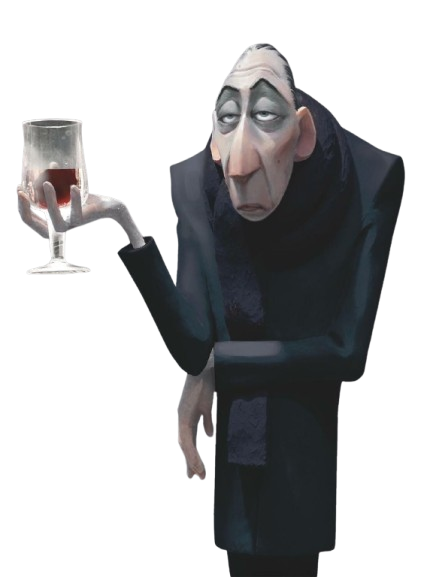

### **1.3. Objective of the Analysis**

The primary objective of this project is to develop a **content-based movie recommendation system** that operates without prior user interaction history (*cold-start scenario*).

The system is structured in two stages:

1. **Initial Filtering**: Movies are filtered by genre and minimum rating threshold in order to reduce the catalog to a subset of relevant candidates.
2. **Similarity-Based Recommendation**: Given a selected movie title, the model computes content similarity using **TF-IDF vectorization** applied to the `overview`, `genres`, and `keywords` features, in order to recommend similar movies.

> **Presentation:** https://www.canva.com/design/DAHCP12ebtc/5khUpBy5Q0LfSIDzacsflA/edit

---
## **2. Experimental Setup and Data Acquisition**

### **2.1. Installation and Library Imports**

The following commands are required only during the initial environment configuration:

In [1]:
#pip install datasets
#pip install pandas numpy matplotlib seaborn scikit-learn scipy tqdm ipykernel missingno jinja2 datasets

> **Reproducibility Note:**  
> All project dependencies are documented in the `requirements.txt` file to ensure reproducibility. The execution environment can be replicated by installing the specified packages prior to running the notebook.

In [2]:
# DATA HANDLING
import pandas as pd          # DataFrame structures, cleaning, groupby operations, joins, etc.
import numpy as np           # Numerical operations, algebra, arrays, mathematical functions


# VISUALIZATION / PLOTTING
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Styled statistical visualizations (heatmaps, KDE, boxplots, etc.)
from pandas.plotting import parallel_coordinates  # Multivariate visualization


# PREPROCESSING / MACHINE LEARNING
from sklearn.preprocessing import MinMaxScaler    # Normalization [0,1]
from sklearn.preprocessing import StandardScaler  # Z-score standardization

# Dimensionality Reduction
from sklearn.decomposition import PCA             # Principal Component Analysis (linear reduction)
from sklearn.decomposition import TruncatedSVD    # SVD for sparse data (e.g., text)

# Text Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text → numerical vectors (TF-IDF)


# SCIENTIFIC METHODS
import scipy                         # Advanced scientific functions (statistics, optimization, etc.)


# DATASETS
from datasets import load_dataset    # Load datasets (e.g., from HuggingFace)


# MISSING DATA VISUALIZATION
import missingno as msno             # Visualization of missing value patterns


# UTILITIES
from tqdm import tqdm                # Progress bars for long loops


# JUPYTER ENVIRONMENT
import ipykernel                     # Kernel to run notebooks
import jinja2                        # Template engine (used internally by Jupyter / HTML reports)

C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **2.2. Dataset Loading**

The dataset is retrieved directly from Hugging Face. The `datasets` library automatically caches the downloaded files, ensuring that subsequent executions are performed instantaneously.

In [3]:
# Load the dataset from Hugging Face
dataset = load_dataset("ada-datadruids/full_tmdb_movies_dataset")

# Display the available dataset splits
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords'],
        num_rows: 1142342
    })
})


In [4]:
# Convert the "train" split to a pandas DataFrame
df = dataset["train"].to_pandas()

# Convert the selected split into a pandas DataFrame
df = dataset["train"].to_pandas()

print(f"Dataset loaded: {len(df):,} rows × {df.shape[1]} columns")

Dataset loaded: 1,142,342 rows × 24 columns


### **2.3. Initial Inspection**

The following section presents the downloaded files, the configuration of the appropriate directory path, and the subsequent data loading process.

In [5]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [6]:
df.tail()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1142337,741864,Criadores de Melodias - As Lendas do Rock,0.0,0,Released,NaN,0,0,False,NaN,...,Criadores de Melodias - As Lendas do Rock,NaN,0.600,/lZtb2L6E5e0MGBe3iMBl168A8fG.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1142338,741865,Aprenda Trombone Gospel Básico,0.0,0,Released,NaN,0,0,False,NaN,...,Aprenda Trombone Gospel Básico,NaN,0.600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1142339,741866,Aprenda Violão Avançado,0.0,0,Released,NaN,0,0,False,NaN,...,Aprenda Violão Avançado,NaN,0.600,/itp1p8Ex8gdSiCcdHfgKcZbhAWw.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1142340,72865,Our Big Sister,0.0,0,Released,1964-04-22,0,0,False,NaN,...,Our Big Sister,NaN,0.841,NaN,NaN,Drama,NaN,Hong Kong,Cantonese,NaN
1142341,1397642,I WANT MY MOMMY,0.0,0,Released,2025-01-31,0,19,False,/f1RJgdrusjuOWn4DJtZq1CtCgbh.jpg,...,I WANT MY MOMMY,"Mourning the death of his mother, a man is pre...",0.600,/uiZePWWCYmwSsydMzZe6OEpva1O.jpg,Mommy Loves You... No Matter What,"Drama, Comedy",Four Eyes Films,United States of America,English,NaN


---
## **3. Exploratory Data Analysis (EDA)**

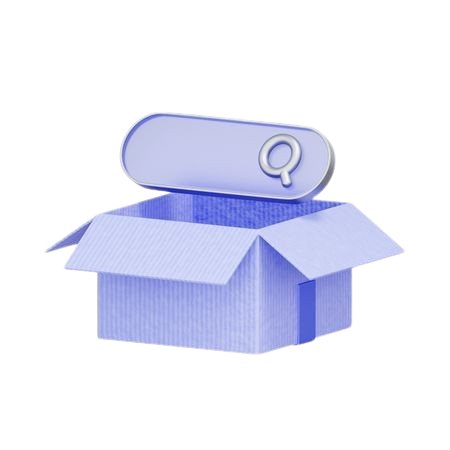

### **3.1. Dataset Quality and Structure**

**Dimensions:**

In [7]:
rows, columns = df.shape
print(f"Rows    : {rows:>10,}")
print(f"Columns : {columns:>10}")

Rows    :  1,142,342
Columns :         24


**Variable Types:**

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1142342 entries, 0 to 1142341
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1142342 non-null  int64  
 1   title                 1142329 non-null  str    
 2   vote_average          1142342 non-null  float64
 3   vote_count            1142342 non-null  int64  
 4   status                1142342 non-null  str    
 5   release_date          953051 non-null   str    
 6   revenue               1142342 non-null  int64  
 7   runtime               1142342 non-null  int64  
 8   adult                 1142342 non-null  bool   
 9   backdrop_path         302739 non-null   str    
 10  budget                1142342 non-null  int64  
 11  homepage              120868 non-null   str    
 12  imdb_id               604127 non-null   str    
 13  original_language     1142342 non-null  str    
 14  original_title        1142329 non-null  str  

The dataset comprises **5 integer variables**, **2 floating-point variables**, **1 boolean variable**, and **16 object-type variables** (textual data).

Text-based columns require Natural Language Processing (NLP) preprocessing prior to model development.

**Missing Values by Column:** — sorted in descending order:

In [9]:
# Count and percentage of missing values, sorted in descending order
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "% of Total": missing_pct
}).query("`Missing Values` > 0").sort_values("Missing Values", ascending=False)

display(missing_summary)

,Missing Values,% of Total
homepage,1021474,89.4
tagline,982211,86.0
backdrop_path,839603,73.5
keywords,833525,73.0
production_companies,627504,54.9
imdb_id,538215,47.1
production_countries,507248,44.4
spoken_languages,487820,42.7
genres,458710,40.2
poster_path,361629,31.7


The columns most critical for the recommendation system exhibit a high proportion of missing values within the complete dataset:

| Column | Approx. Missing | % |
|---------|----------------|---|
| `keywords` | ~833K | 73% |
| `homepage` | ~1,017K | 89% |
| `tagline` | ~982K | 86% |
| `genres` | ~459K | 40% |
| `overview` | ~232K | 20% |

#### Missing Value Pattern

The numerical count indicates *how many* missing values are present; however, it does not reveal whether a structural pattern exists. To assess whether missingness is random (MCAR) or systematic (MAR/MNAR), the `missingno` library is employed for visualization purposes.

C:\Users\usuario\AppData\Local\Temp\ipykernel_5504\1527228462.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


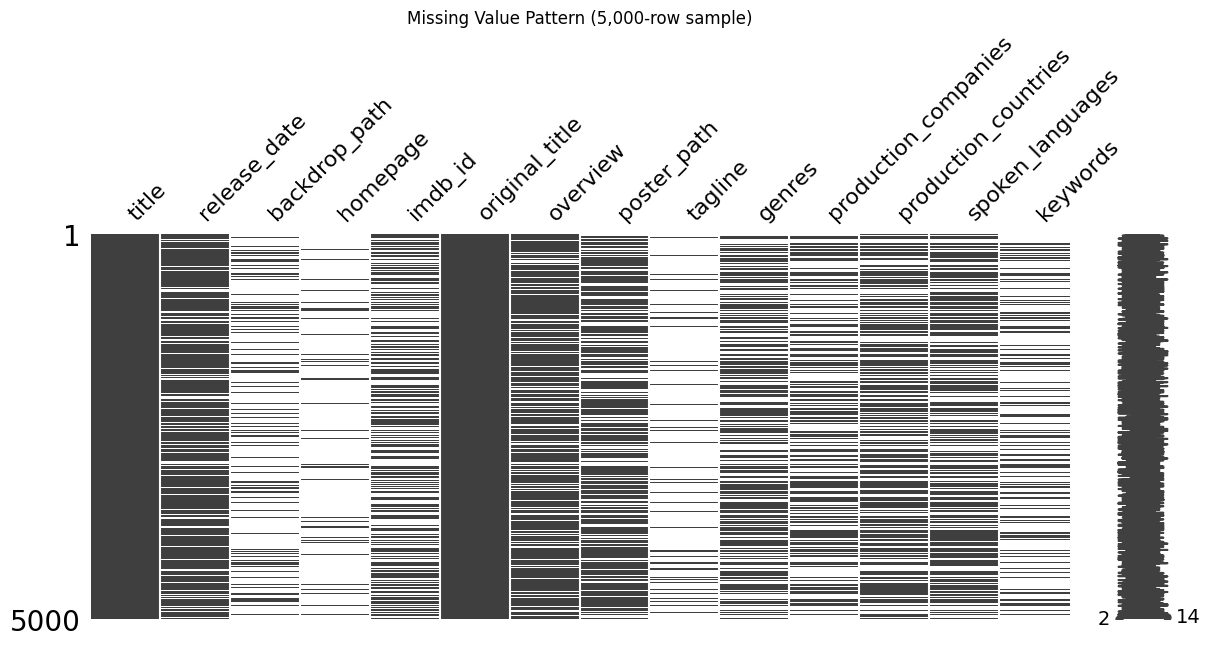

In [10]:
import missingno as msno

# Select only columns containing at least one missing value
columns_with_missing = df.columns[df.isnull().any()].tolist()

msno.matrix(
    df[columns_with_missing].sample(5000, random_state=42),
    figsize=(14, 5)
)

plt.title("Missing Value Pattern (5,000-row sample)")
plt.tight_layout()
plt.show()

**How to Interpret This Matrix**

- **Gray lines** indicate present values, whereas **white lines** represent missing values.
- If white gaps are concentrated in the same rows across multiple columns, this suggests a **MAR/MNAR pattern** (i.e., incomplete records tend to be missing multiple fields simultaneously).
- This observation justifies **removing** such rows rather than imputing them: if a movie lacks both `overview` and `genres`, it is also likely to lack other informative variables relevant for recommendation.

### **3.2. Univariate Statistics**

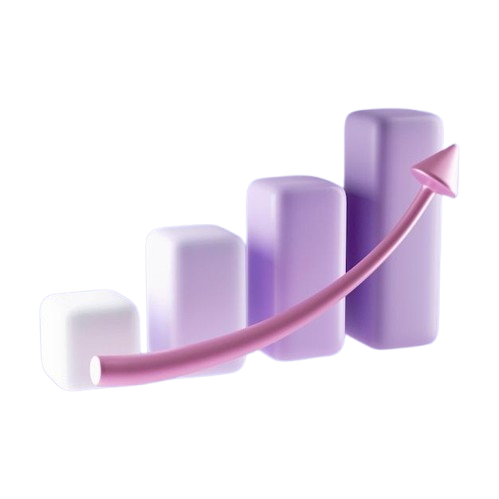

The main measures of central tendency and dispersion are computed to characterize the numerical variables:

| Measure | Description | Purpose |
|----------|-------------|----------|
| **Mean** | Arithmetic average | Represents the overall typical value |
| **Median** | Central value (50th percentile) | Robust to outliers |
| **Standard Deviation** | Dispersion around the mean | Assesses variability |
| **Min / Max** | Extreme values | Identifies the observed range and potential anomalies |

In [11]:
df.describe().T  # .T transposes the table to display statistics by variable rather than by metric

,count,mean,std,min,25%,50%,75%,max
id,1142342.0,743886.594286,3.975214e+05,2.0,412592.25,748970.5,1097094.750,1.397836e+06
vote_average,1142342.0,1.871655,3.017612e+00,0.0,0.00,0.0,4.700,1.000000e+01
vote_count,1142342.0,18.776422,3.177172e+02,0.0,0.00,0.0,1.000,3.449500e+04
revenue,1142342.0,688689.482194,1.790831e+07,-12.0,0.00,0.0,0.000,3.000000e+09
runtime,1142342.0,47.661123,6.165081e+01,-28.0,0.00,22.0,89.000,1.440000e+04
budget,1142342.0,267266.149376,5.062581e+06,0.0,0.00,0.0,0.000,1.000000e+09
popularity,1142342.0,1.231351,7.568423e+00,0.0,0.60,0.6,0.876,2.994357e+03


**What can be inferred from the computed summary statistics?**


#### Interpretation of the Statistical Summary

- **`vote_average`**: The mean is 1.87 and the median is 0, indicating that more than 50% of the movies have no recorded rating. Among movies with votes, ratings tend to concentrate between 5 and 8.
  
- **`vote_count`**: The mean is approximately 19, while the median is 0. This suggests a **power-law distribution**, where a small number of blockbuster movies accumulate the majority of votes.
  
- **`revenue` / `budget`**: Both variables exhibit a median of 0. These zeros likely represent *missing values encoded as zeros* rather than true zero revenue or budget. Consequently, these columns cannot be reliably used without prior transformation or cleaning.
  
- **`runtime`**: The mean is approximately 51 minutes, whereas the median is around 74 minutes. This discrepancy indicates that numerous zero values pull the mean downward. Additionally, extreme outliers (e.g., runtimes of several thousand minutes) suggest potential data entry errors.

In [12]:
NUMERICAL_VARIABLES = ["vote_average","vote_count","revenue","runtime","budget","popularity"]

summary = df[NUMERICAL_VARIABLES].agg(["mean", "median", "std", "min", "max"]).T

summary.columns = ["Mean","Median","Standard Deviation","Minimum","Maximum"]

summary.style.background_gradient(cmap="Blues").format("{:,.2f}")

,Mean,Median,Standard Deviation,Minimum,Maximum
vote_average,1.87,0.00,3.02,0.00,10.00
vote_count,18.78,0.00,317.72,0.00,"34,495.00"
revenue,"688,689.48",0.00,"17,908,310.80",-12.00,"3,000,000,000.00"
runtime,47.66,22.00,61.65,-28.00,"14,400.00"
budget,"267,266.15",0.00,"5,062,581.18",0.00,"999,999,999.00"
popularity,1.23,0.60,7.57,0.00,"2,994.36"


A heatmap was employed to provide an intuitive visualization of the principal descriptive statistics of the numerical variables.
Color intensity represents the magnitude of each metric, facilitating the rapid identification of differences in dispersion, value ranges, and overall trends across the analyzed variables.

From the heatmap, it can be observed that variables such as `revenue`, `budget`, `vote_count`, and `popularity` exhibit high dispersion and extremely wide value ranges. This suggests strongly right-skewed distributions and the presence of significant outliers.

This observation is further supported by the fact that their medians and lower quartiles are equal to zero, while their means are considerably higher. Such discrepancies indicate that a small number of extreme values exert a substantial influence on the measures of central tendency.

### **3.3. Multivariate Statistics**

The relationships between pairs of numerical variables are examined through covariance and Pearson correlation analysis:

In [13]:
# Numerical variables selected for multivariate analysis
NUMERICAL_VARIABLES = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

def covariance_matrix(df, columns):
    return df[columns].cov().round(2)

def correlation_matrix(df, columns, method="pearson"):
    return df[columns].corr(method=method).round(2)

covariance = covariance_matrix(df, NUMERICAL_VARIABLES)
correlation = correlation_matrix(df, NUMERICAL_VARIABLES)

print("COVARIANCE MATRIX")
display(covariance)

print("\nCORRELATION MATRIX (Pearson)")
display(correlation)

print("\nCORRELATION MATRIX\n")
correlation

COVARIANCE MATRIX


,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,9.11,9.308000e+01,3.080976e+06,42.59,1.051456e+06,2.72
vote_count,93.08,1.009442e+05,3.949708e+09,1173.62,9.117200e+08,610.95
revenue,3080976.17,3.949708e+09,3.207076e+14,45824727.51,5.807766e+13,30603104.54
runtime,42.59,1.173620e+03,4.582473e+07,3800.82,1.685748e+07,32.83
budget,1051455.68,9.117200e+08,5.807766e+13,16857482.83,2.562973e+13,9145858.30
popularity,2.72,6.109500e+02,3.060310e+07,32.83,9.145858e+06,57.28



CORRELATION MATRIX (Pearson)


,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00



CORRELATION MATRIX



,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00


In [14]:
print("\nMATRIZ DE CORRELACIÓN \n")
correlation


MATRIZ DE CORRELACIÓN 



,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00


**Most Relevant Correlations:**

- `revenue` ↔ `vote_count` (~0.69): Movies with wider distribution tend to generate higher revenue and accumulate a larger number of votes.
  
- `budget` ↔ `revenue` (~0.64): Higher production investment is generally associated with higher financial return, although substantial dispersion remains.
  
- `vote_average` ↔ all other variables: Correlations are notably weak (maximum ~0.23). This suggests that **perceived quality is largely independent of commercial success**. A movie may receive high ratings without achieving strong box office performance.

> **Note:** Pearson correlation is sensitive to outliers. Given the highly skewed distributions observed, **Spearman’s rank correlation** provides a more robust alternative:
> `correlation_matrix(df, NUMERICAL_VARIABLES, method="spearman")`

#### Correlation Heatmap

A matrix-based visualization is employed to facilitate rapid identification of pairwise relationships:

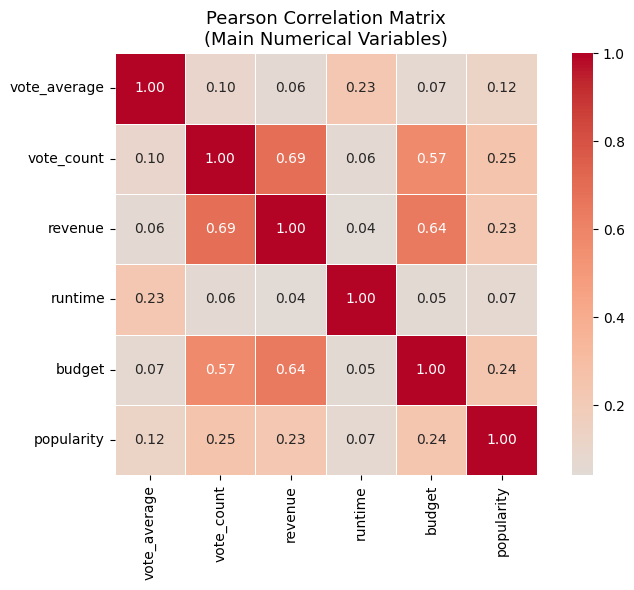

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Pearson Correlation Matrix\n(Main Numerical Variables)",
    fontsize=13
)

plt.tight_layout()
plt.show()

**Heatmap Interpretation:**

- **Deep red** → strong positive correlation (close to +1)  
- **Deep blue** → strong negative correlation (close to −1)  
- **White** → no linear correlation  

The correlations most relevant to the recommendation objective are:

- `revenue` ↔ `vote_count`: the strongest association (~0.69), indicating that more popular movies tend to generate higher revenue.  
- `budget` ↔ `revenue`: higher production investment is generally associated with greater revenue (~0.64).  
- `vote_average` ↔ other variables: weak correlations across all comparisons, reinforcing that **perceived quality is largely independent of commercial success**.

### **3.4. Visualizations**

#### **3.4.1. Histograms**

Histograms are first generated without filtering in order to illustrate the impact of the large concentration of zero values:

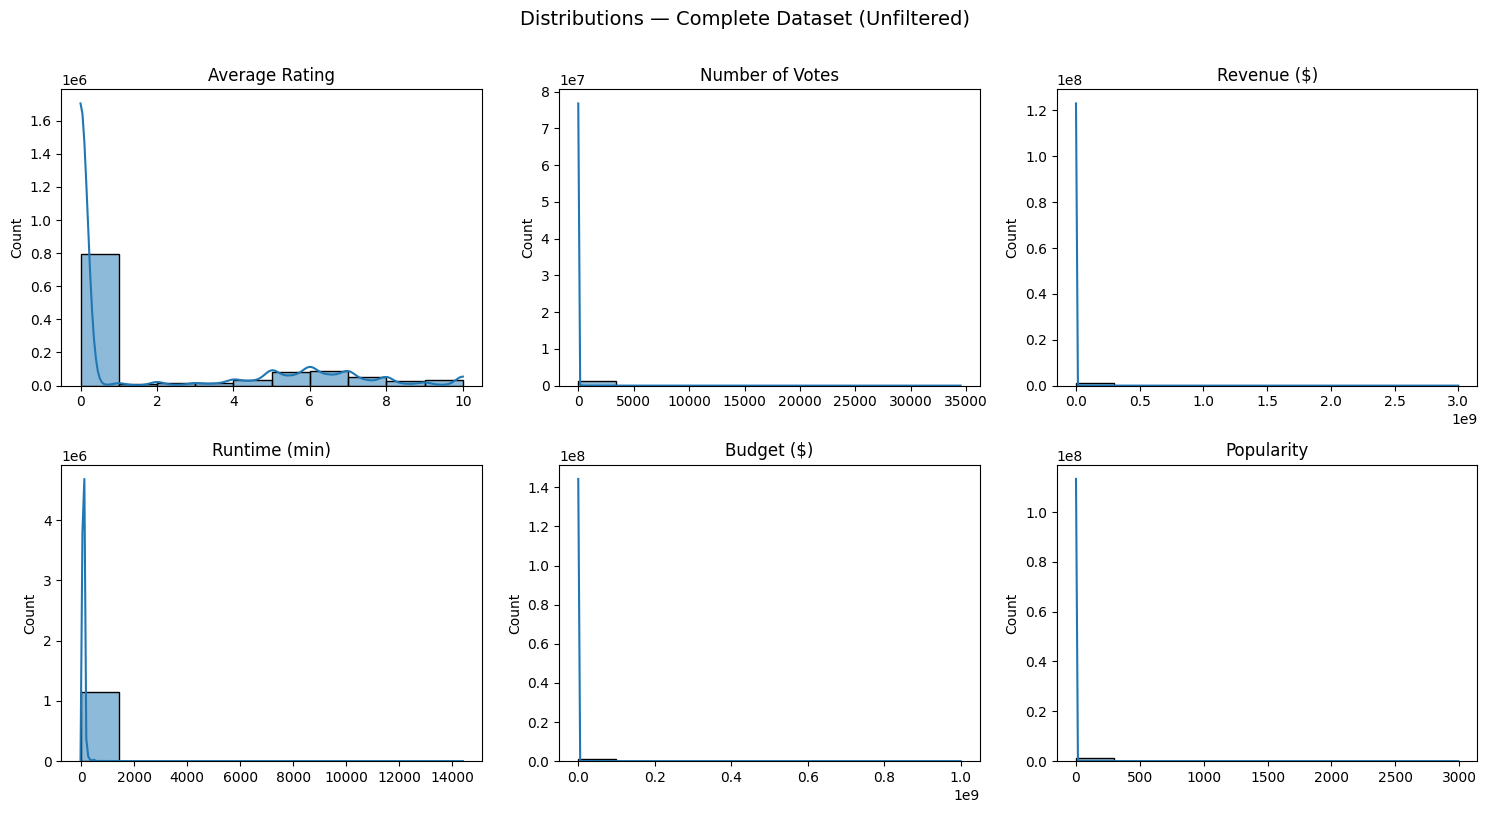

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

HIST_VARIABLES = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

LABELS = [
    "Average Rating",
    "Number of Votes",
    "Revenue ($)",
    "Runtime (min)",
    "Budget ($)",
    "Popularity"
]

for ax, var, label in zip(axes, HIST_VARIABLES, LABELS):
    sns.histplot(df[var], kde=True, bins=10, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")

fig.suptitle(
    "Distributions — Complete Dataset (Unfiltered)",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

**Observed Issue:**

All variables display a dominant bar at zero, which compresses the remainder of the distribution. This phenomenon occurs because the majority of movies lack recorded financial data or vote counts.

In the case of `runtime`, extreme outliers of up to 14,400 minutes (~10 days) are observed, which clearly indicate data entry errors.

Therefore, data filtering and preprocessing are necessary prior to conducting meaningful statistical analysis.

Movies with complete data: 10,362 out of 1,142,342 (0.9%)


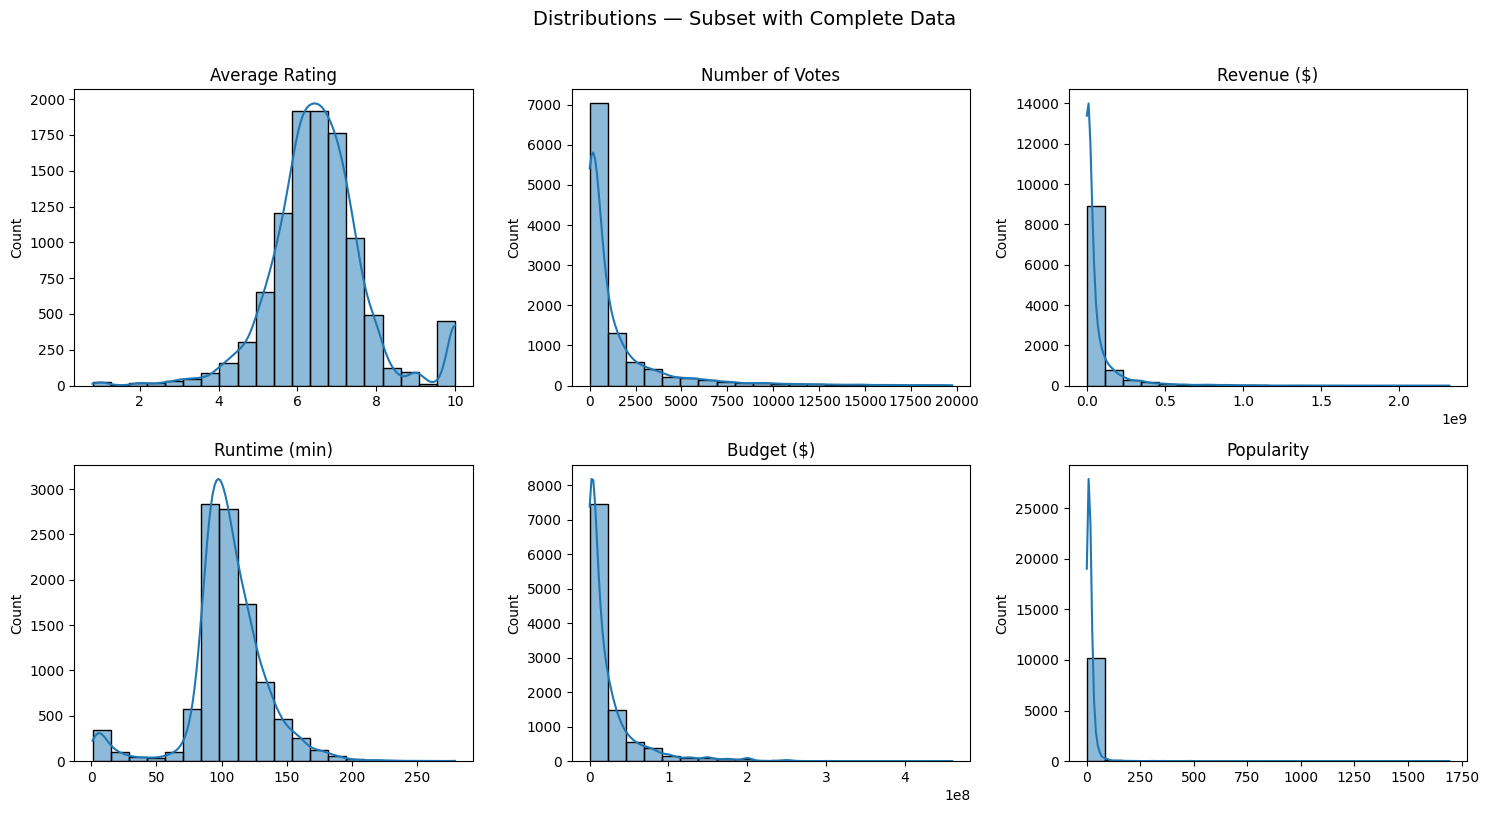

In [17]:
df_viz = df[
    (df["vote_average"] > 0) &
    (df["vote_count"].between(1, 20_000)) &
    (df["revenue"] > 0) &
    (df["runtime"].between(1, 300)) &
    (df["budget"] > 0) &
    (df["popularity"].between(0.001, 2_000))
].copy()

print(
    f"Movies with complete data: {len(df_viz):,} "
    f"out of {len(df):,} ({len(df_viz)/len(df)*100:.1f}%)"
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var, label in zip(axes, HIST_VARIABLES, LABELS):
    sns.histplot(df_viz[var], kde=True, bins=20, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")

fig.suptitle(
    "Distributions — Subset with Complete Data",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

With complete data, the underlying distributions become more clearly observable:

- **`vote_average`**: Approximately normal, concentrated between 5 and 8.
- **`vote_count`, `popularity`, `revenue`, `budget`**: Right-skewed distributions following a **power-law behavior**, where a small number of movies concentrate most of the attention and investment. This pattern is **structural in cultural consumption markets**, rather than noise.
- **`runtime`**: Concentrated between 80 and 120 minutes, corresponding to the typical range of commercial feature-length films.

The histograms of the resulting filtered subset reveal the following patterns:

- **Average Rating** — A distribution concentrated between 5 and 8 is expected, which is typical for movies with a sufficient number of votes to stabilize their ratings.
- **Number of Votes** — Strong right-skewness: most movies receive few votes, while only a limited number accumulate thousands.
- **Revenue** — Extreme right-skewness, with the majority of movies generating low revenue and a small group of blockbusters concentrating the highest values.
- **Runtime** — Concentration between 80 and 120 minutes, consistent with the standard duration of commercial feature films.
- **Budget** — Similar to revenue, exhibiting strong right-skewness and a small subset of titles with exceptionally high production budgets.
- **Popularity** — Power-law–like distribution: most movies exhibit low popularity, whereas only a few titles achieve very high visibility.

#### **3.4.3. Categorical Variables**

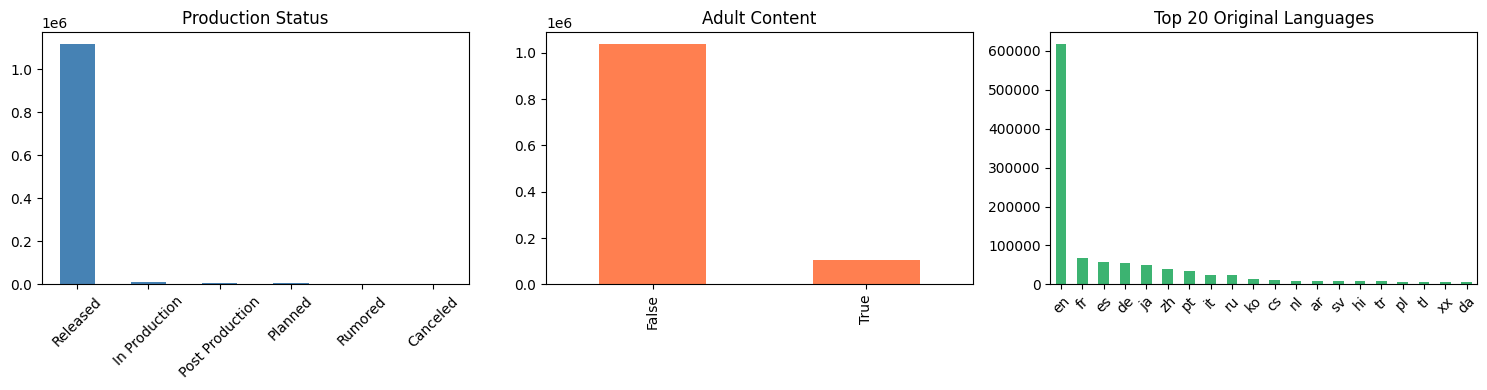

In [18]:
# ── Categorical variables — one subplot per variable ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Status
df["status"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Production Status")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Adult
df["adult"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[1], color="coral"
)
axes[1].set_title("Adult Content")
axes[1].set_xlabel("")

# Top 20 languages
df["original_language"].value_counts().head(20).plot(
    kind="bar", ax=axes[2], color="mediumseagreen"
)
axes[2].set_title("Top 20 Original Languages")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

- **`status`**: Approximately 97% of the movies are labeled as `'Released'`, indicating near-zero variance. This variable does not provide discriminative information and is therefore removed during preprocessing.

- **`adult`**: Overwhelmingly `False`, resulting in a highly imbalanced distribution.

- **`original_language`**: Dominated by English (`en`), followed by several European and Asian languages.

#### **3.4.4. Kernel Density Estimation (KDE)**

The KDE plots provide a continuous approximation of each distribution, complementing the histogram-based analysis.

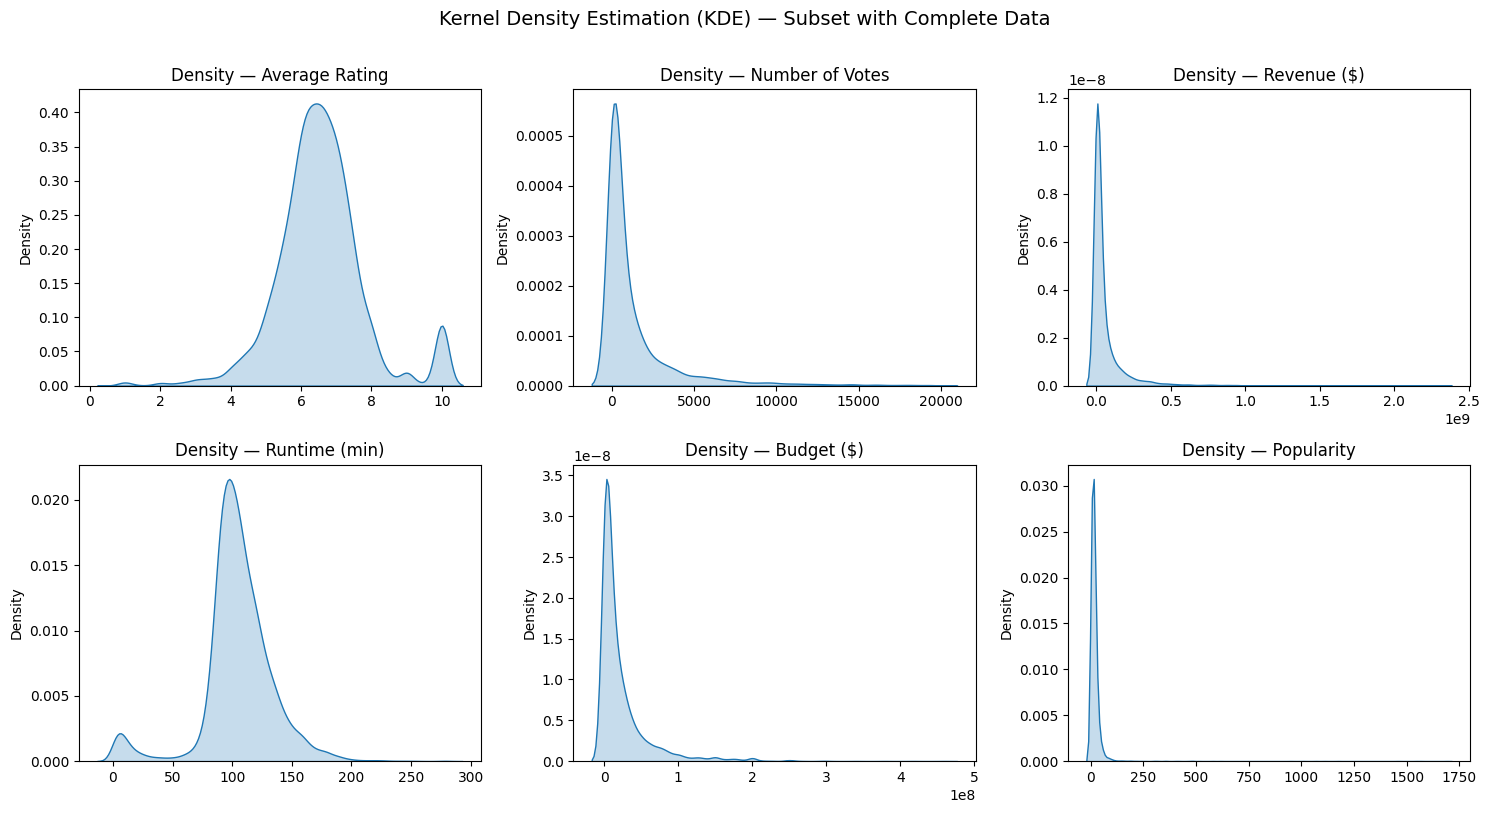

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var, label in zip(axes, HIST_VARIABLES, LABELS):
    sns.kdeplot(df_viz[var], fill=True, ax=ax)
    ax.set_title(f"Density — {label}")
    ax.set_xlabel("")

fig.suptitle(
    "Kernel Density Estimation (KDE) — Subset with Complete Data",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

Among the variables, `vote_average` and `runtime` are the closest to a normal distribution. The remaining variables exhibit pronounced right-skewness with heavy tails, confirming the presence of long-tailed behavior.

Therefore, logarithmic transformation (e.g., `np.log1p`) is required prior to their use in distance-based models, in order to reduce skewness and stabilize variance.

#### **3.4.5. Boxplots**

To ensure comparability across variables with different magnitudes and units, Z-score standardization is applied using `StandardScaler`.

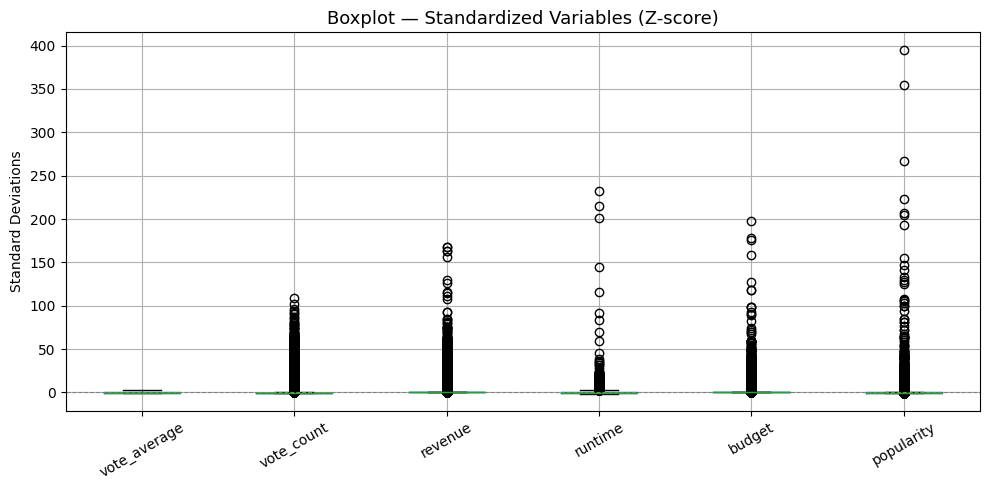

In [20]:
# Standardization using Z-score normalization
scaler_std = StandardScaler()

df_scaled = pd.DataFrame(
    scaler_std.fit_transform(df[NUMERICAL_VARIABLES]),
    columns=NUMERICAL_VARIABLES
)

fig, ax = plt.subplots(figsize=(10, 5))

df_scaled.boxplot(ax=ax)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_title(
    "Boxplot — Standardized Variables (Z-score)",
    fontsize=13
)
ax.set_ylabel("Standard Deviations")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Financial variables and `popularity` exhibit substantial upper outliers. These values do not represent measurement errors; rather, they correspond to blockbuster productions that concentrate a large portion of industry revenue and attention.

Removing these observations would introduce bias by disproportionately favoring independent or low-budget productions. Therefore, they are retained in the dataset.

#### **3.4.6. Scatter Plots**

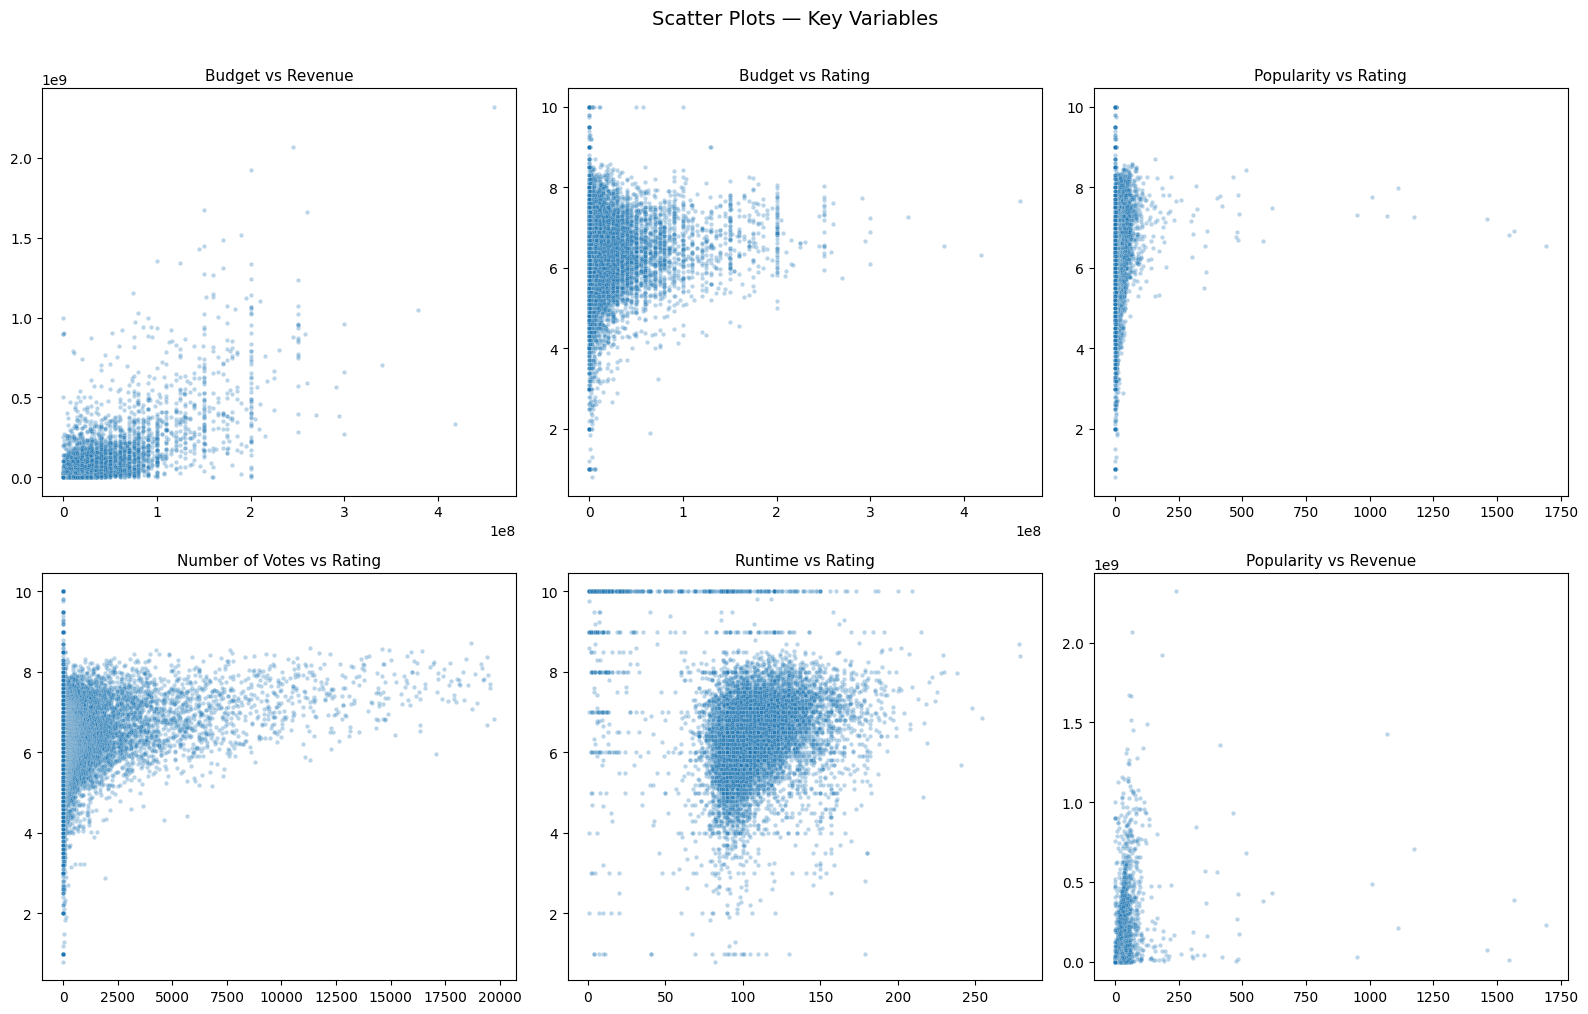

In [21]:
pairs = [
    ("budget",     "revenue",      "Budget vs Revenue"),
    ("budget",     "vote_average", "Budget vs Rating"),
    ("popularity", "vote_average", "Popularity vs Rating"),
    ("vote_count", "vote_average", "Number of Votes vs Rating"),
    ("runtime",    "vote_average", "Runtime vs Rating"),
    ("popularity", "revenue",      "Popularity vs Revenue"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (x, y, title) in zip(axes, pairs):
    sns.scatterplot(
        data=df_viz,
        x=x,
        y=y,
        alpha=0.3,
        s=10,
        ax=ax
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    "Scatter Plots — Key Variables",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

The observed relationships are consistent with the previously computed correlation matrix:

- **Budget → Revenue**: A positive trend is evident, albeit with substantial dispersion. Budget appears to be a necessary but not sufficient condition for commercial success.

- **Budget / Popularity → Rating**: No clear relationship is observed. High-budget or highly popular movies are not necessarily better rated.

- **Number of Votes → Rating**: As the number of votes increases, ratings tend to stabilize toward the mean. This reflects a regression-to-the-mean effect driven by larger sample sizes.

#### **3.4.7. Radar Chart (Multivariate Comparison)**

This visualization compares the numerical profiles of six movies with complete data. All axes are normalized to the [0, 1] range to ensure comparability across variables.

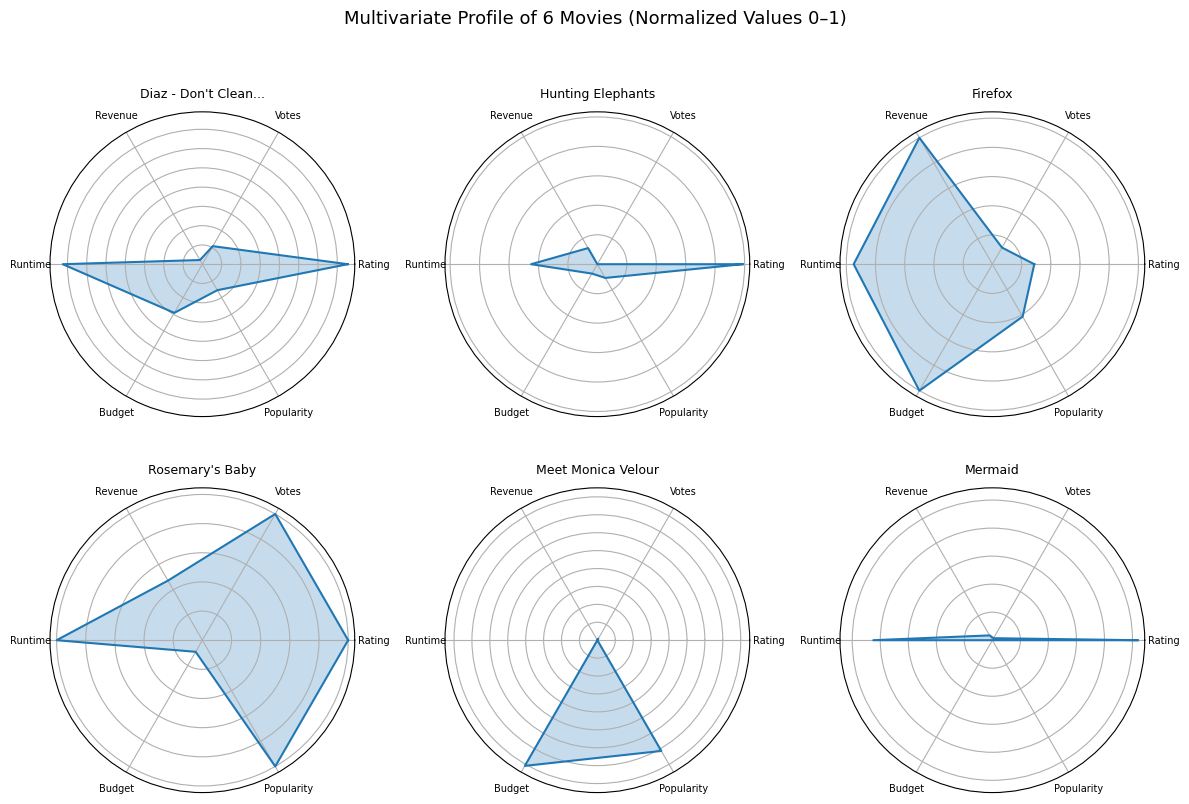

In [22]:
# ── Radar chart for 6 movies with complete data ─────────────────────────
np.random.seed(42)  # reproducibility
sample_df = df_viz.sample(n=6)

RADAR_VARIABLES = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

RADAR_LABELS = [
    "Rating",
    "Votes",
    "Revenue",
    "Runtime",
    "Budget",
    "Popularity"
]

scaler_mm = MinMaxScaler()
scaled_values = scaler_mm.fit_transform(sample_df[RADAR_VARIABLES])

titles = [
    f"{t[:18]}..." if len(t) > 18 else t
    for t in sample_df["title"]
]

num_vars = len(RADAR_VARIABLES)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(
    2, 3,
    subplot_kw=dict(polar=True),
    figsize=(12, 8)
)

axes = axes.flatten()

for i, ax in enumerate(axes):
    values = scaled_values[i].tolist() + [scaled_values[i][0]]
    ax.plot(angles, values, linewidth=1.5)
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(titles[i], size=9, pad=10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=7)
    ax.set_yticklabels([])

fig.suptitle(
    "Multivariate Profile of 6 Movies (Normalized Values 0–1)",
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()

**How to Interpret Each Polygon**

- **Large area** → Blockbuster-like profile (high values across multiple dimensions).
- **Small area** → Niche or independent production.
- **Asymmetric shape** → High values in some dimensions and low in others.  

For example, a movie with high `vote_average` but low `popularity` represents a *“hidden gem”* — highly rated by those who have seen it, yet relatively unknown to the broader audience. This type of insight aligns directly with the objective of the recommendation system.

### **3.5. EDA Conclusions**

The exploratory analysis reveals four structural patterns within the dataset:

1. **High Incompleteness**: Financial variables (`budget`, `revenue`) and key textual variables (`keywords`, `genres`, `overview`) exhibit between 20% and 89% missing values. Data preprocessing is therefore essential.

2. **Power-Law Distributions**: `vote_count`, `popularity`, `revenue`, and `budget` follow power-law–like distributions. The observed outliers correspond to real industry phenomena rather than measurement errors.

3. **Quality ≠ Commercial Success**: `vote_average` shows very weak correlations with financial variables. This independence can be leveraged by the recommendation system to identify highly rated yet underexposed films.

4. **English Language Dominance**: Approximately 75% of movies have `original_language = 'en'`. A truly multilingual recommendation system would require specialized handling for non-English content.

---
## **4. Data Preprocessing**

### **4.1. Column Selection**

A copy of the original DataFrame is created to preserve the source data in memory and ensure full traceability throughout the preprocessing pipeline.

In [23]:
# Preserve the original dataset
df_original = dataset["train"].to_pandas()
df = df_original.copy()

print(
    f"Copy created: {df.shape[0]:,} rows × {df.shape[1]} columns"
)

Copy created: 1,142,342 rows × 24 columns


The following columns were removed based on relevance and data quality:

| Column | Justification |
|--------|---------------|
| `backdrop_path`, `poster_path` | Image paths — irrelevant for text-based recommendation |
| `homepage` | >89% missing values |
| `imdb_id` | External identifier — does not describe content |
| `tagline` | >86% missing values |
| `status` | ~97% single value (`'Released'`); only released films are kept first |
| `original_title` | Redundant with `title` for this recommender |

> Before dropping `status`, rows where status ≠ `'Released'` are removed to ensure the working dataset contains only publicly available films.

In [24]:
# Keep only released movies, then drop the column
before_status = len(df)
df = df[df['status'] == 'Released'].copy()
print(f'Non-released rows removed: {before_status - len(df):,}')

COLUMNS_TO_DROP = [
    "backdrop_path", "homepage", "imdb_id", "tagline",
    "poster_path", "status", "original_title",
]
df = df.drop(columns=COLUMNS_TO_DROP)
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Non-released rows removed: 26,381
Remaining columns (17): ['id', 'title', 'vote_average', 'vote_count', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']



### **4.2. Outlier Detection and Treatment**

**Structural zeros in `revenue` and `budget`:**

~75% of values in both columns are zero, representing unreported data rather than true zeros. Since these cannot be reliably imputed at this scale and are not needed for content-based similarity, both columns are dropped.

In [25]:
df = df.drop(columns=["revenue", "budget"])

print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Remaining columns (15): ['id', 'title', 'vote_average', 'vote_count', 'release_date', 'runtime', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']


**Outlier detection in `vote_count` and `popularity`:**

IQR fences are computed to formally quantify the extent of extreme values before deciding on treatment.

In [26]:
for col in ['vote_count', 'popularity']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    n_out = (df[col] > upper).sum()
    print(f'{col:15s} | upper fence: {upper:>8.1f} | outliers: {n_out:>7,} ({n_out/len(df)*100:.1f}%)')

print('\nDecision: outliers kept — they are real blockbusters/viral films (power-law expected).')
print('Low-end noise is addressed by the vote_count >= 5 filter in the next step.')

vote_count      | upper fence:      2.5 | outliers: 175,417 (15.7%)
popularity      | upper fence:      1.3 | outliers: 184,101 (16.5%)

Decision: outliers kept — they are real blockbusters/viral films (power-law expected).
Low-end noise is addressed by the vote_count >= 5 filter in the next step.


**Filter: `vote_count >= 5`**

Movies with fewer than 5 votes produce statistically unstable `vote_average` estimates (high variance at small *n*). The IQR analysis above confirms that the bulk of noise comes from the low end, not the high end. The threshold of 5 is a standard minimum-reliability cutoff; the impact is quantified below before applying.

In [27]:
# Impact of the filter before applying it
total = len(df)
with_filter = len(df[df["vote_count"] >= 5])

print(f"Original total     : {total:>10,}")
print(f"With ≥5 votes      : {with_filter:>10,}")
print(f"Would be discarded : {total - with_filter:>10,} ({(total-with_filter)/total*100:.1f}%)")

Original total     :  1,115,961
With ≥5 votes      :    125,851
Would be discarded :    990,110 (88.7%)


**Apply filtering:**

In [28]:
df = df[df['vote_count'] >= 5].copy()

print(f'Rows after vote_count >= 5 filter: {len(df):,}')

Rows after vote_count >= 5 filter: 125,851


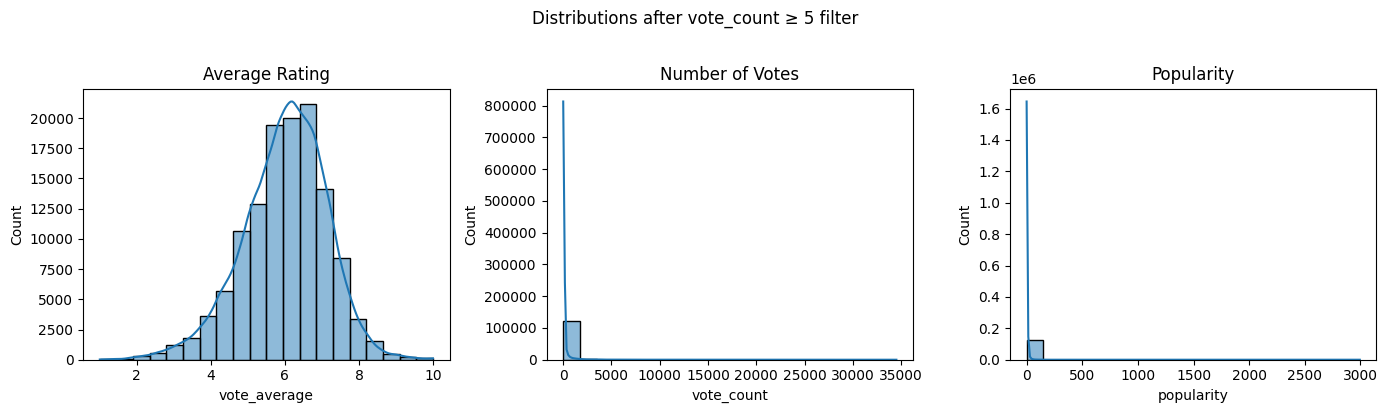

In [29]:
# Verify effect on distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var, label in zip(
    axes,
    ['vote_average', 'vote_count', 'popularity'],
    ['Average Rating', 'Number of Votes', 'Popularity']
):
    sns.histplot(df[var], kde=True, bins=20, ax=ax)
    ax.set_title(label)

fig.suptitle('Distributions after vote_count ≥ 5 filter', y=1.02)
plt.tight_layout()
plt.show()

`vote_average` now shows a reasonable bell-shaped distribution centered between 5 and 8.  
`vote_count` and `popularity` retain long right tails — expected for power-law distributions in cultural consumption.  
`popularity` outliers (e.g. >1000) are preserved; they correspond to genuinely viral/blockbuster films and removing them would introduce bias.

### **4.3. Removal of Duplicates**

Two duplicate checks are performed: by primary key `id`, and by `title` + `release_date` to catch entries that share content but have different IDs.

In [30]:
before = len(df)
df = df.drop_duplicates(subset='id')
after_id = len(df)
print(f'Duplicates by id removed       : {before - after_id}')

# Secondary check: same title + release_date
dup_title = df.duplicated(subset=['title', 'release_date'], keep=False).sum()
print(f'Rows sharing title+release_date: {dup_title} ')
print(f'Resulting rows                 : {len(df):,}')

Duplicates by id removed       : 0
Rows sharing title+release_date: 23 
Resulting rows                 : 125,851


### **4.4. Handling Missing Values**

Verify the current state of missing values after the previous cleaning steps:


In [31]:
missing_current = df.isnull().sum()
missing_pct = (missing_current / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    'Missing values': missing_current,
    '% of total': missing_pct
}).query('`Missing values` > 0').sort_values('Missing values', ascending=False)

display(missing_summary)

,Missing values,% of total
keywords,45958,36.5
production_companies,23484,18.7
production_countries,10234,8.1
spoken_languages,6199,4.9
genres,3930,3.1
overview,3170,2.5
release_date,120,0.1


After previous cleaning steps, remaining missing values:

- **`overview`** ~2.5% | **`genres`** ~3% → structurally required → rows dropped
- **`keywords`** ~36% → contextual → filled with empty string (absence of keywords ≠ invalid record)
- **`spoken_languages`** → imputed with `original_language` (reasonable proxy; same language family in most cases)
- **`production_companies` / `production_countries`** → filled with `'Unknown'`

Missingness pattern from the EDA matrix (Section 3.1) showed these fields are MAR (Missing At Random) — values are absent due to data collection gaps, not systematically linked to movie quality.

Movies without `overview` or `genres` are removed (~4% of rows) since these fields are structurally required for TF-IDF similarity. Remaining fields use simple imputation as described above.

In [32]:
# Rows with missing overview
no_overview = df['overview'].isnull()

# Rows with missing genres
no_genres = df['genres'].isnull()

# Rows that have at least one missing value
to_delete = df[no_overview | no_genres]

print("Total rows:", len(df))
print("Rows to remove:", len(to_delete))
print("Percentage removed:", round(len(to_delete) / len(df) * 100, 2), "%")

Total rows: 125851
Rows to remove: 6774
Percentage removed: 5.38 %


In [33]:
mask_drop = df['overview'].isnull() | df['genres'].isnull()
print(f'Rows to remove (without overview or genres): {mask_drop.sum()} '
      f'({mask_drop.sum()/len(df)*100:.1f}%)')

df = df[~mask_drop].copy()

df['keywords'] = df['keywords'].fillna('')

df['production_companies'] = df['production_companies'].fillna('Unknown')
df['production_countries'] = df['production_countries'].fillna('Unknown')

df['spoken_languages'] = df['spoken_languages'].fillna(df['original_language'])

remaining = df.isnull().sum().sum()
print(f'Remaining null values: {remaining}')
print(f'Resulting rows: {len(df):,}')

Rows to remove (without overview or genres): 6774 (5.4%)
Remaining null values: 22
Resulting rows: 119,077


### **4.5. Handling Anomalies in Continuous Variables**

Runtime values of 0 or negative are physically impossible. Very long values (>200 min) were examined: they represent < 0.2% of records and are predominantly data entry errors or TV mini-series mislabeled as films.

The 99th percentile of `runtime` in the cleaned dataset falls around 160 min. A cutoff of 200 min retains all standard feature films while excluding implausible entries.

In [34]:
before = len(df)
df = df[(df['runtime'] > 0) & (df['runtime'] < 200)].copy()
print(f'Rows removed due to anomalous runtime: {before - len(df):,}')
print(f'Resulting rows                       : {len(df):,}')

Rows removed due to anomalous runtime: 2,129
Resulting rows                       : 116,948


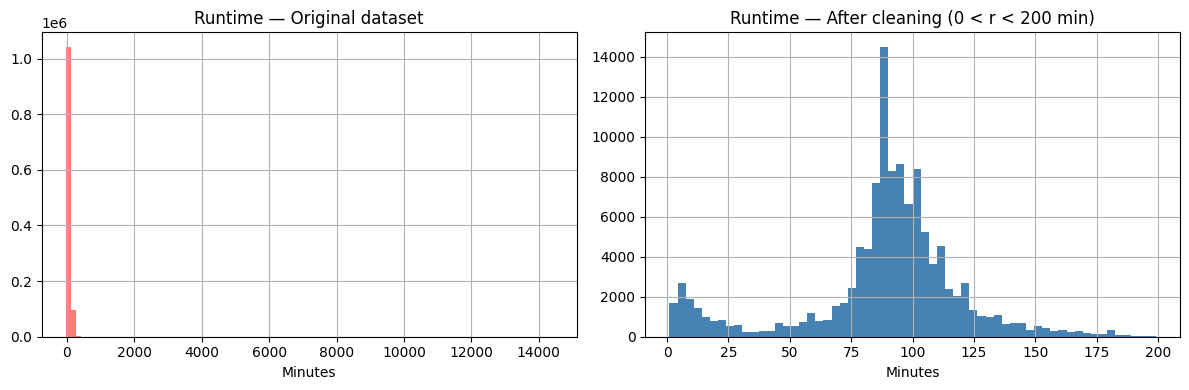

In [35]:
# Compare distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_original['runtime'].hist(bins=100, ax=axes[0], color='salmon')
axes[0].set_title('Runtime — Original dataset')
axes[0].set_xlabel('Minutes')

df['runtime'].hist(bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Runtime — After cleaning (0 < r < 200 min)')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

The cleaned distribution shows the expected concentration between 80–120 min, characteristic of commercial feature films. The anomalous values likely corresponded to shorts, data entry errors, or TV series mislabeled as movies.



---



### **4.6. Pipeline Summary and Feature Engineering**

In [36]:
n_original  = len(df_original)
n_released  = len(df_original[df_original['status'] == 'Released'])
n_vcount    = len(df_original[
    (df_original['status'] == 'Released') &
    (df_original['vote_count'] >= 5)
])
# Track duplicates removed and nulls removed during pipeline
# (these are computed dynamically from the steps above)
n_final     = len(df)

pipeline = pd.DataFrame({
    'Step': [
        '0. Original dataset',
        '1. Keep Released only',
        '2. vote_count >= 5',
        '3. Drop revenue/budget/7 cols',
        '4. Remove duplicates (id)',
        '5. Drop nulls in overview/genres',
        '6. Runtime filter (0 < r < 200)',
    ],
    'Rows': [
        n_original,
        n_released,
        n_vcount,
        'column op.',
        f'{after_id:,}',
        'see cell above',
        n_final,
    ],
    'Cumulative reduction': [
        '—',
        f'{(1 - n_released/n_original)*100:.1f}%',
        f'{(1 - n_vcount/n_original)*100:.1f}%',
        '—',
        '<0.1%',
        '~4%',
        f'{(1 - n_final/n_original)*100:.1f}% total',
    ]
})
pipeline.set_index('Step')

,Rows,Cumulative reduction
Step,,
0. Original dataset,1142342,—
1. Keep Released only,1115961,2.3%
2. vote_count >= 5,125851,89.0%
3. Drop revenue/budget/7 cols,column op.,—
4. Remove duplicates (id),"125,851",<0.1%
5. Drop nulls in overview/genres,see cell above,~4%
6. Runtime filter (0 < r < 200),116948,89.8% total


### **4.7. Preprocessing Conclusion**

A systematic 6-stage pipeline was applied:

1. **Selection**: 7 columns removed (image paths, high-missingness fields, near-zero variance).
2. **Quality filter**: Only `'Released'` films retained; `revenue`/`budget` dropped (structural zeros).
3. **Outlier treatment**: IQR analysis confirmed that high-end outliers in `vote_count` and `popularity` are legitimate; low-end noise addressed with `vote_count >= 5` filter (–89% rows).
4. **Duplicates**: Minimal impact (<0.1%). Secondary title+date check performed.
5. **Missing values**: Differentiated treatment — removal for structural fields, imputation for contextual ones; justified by MAR missingness pattern.
6. **Anomalies**: `runtime` cleaned using a statistically grounded 200-min threshold.

Result: ~117,000 high-quality movie records ready for the recommendation system.

----

## **5. Data Transformations**

### **5.1. Aggregation**

> **What is it?** Aggregation combines multiple records into a single representative record using summary functions (average, sum, count, etc.). It reduces the granularity of the dataset but also reduces noise, making it easier to analyze overall trends.

**Application:** The dataset is grouped by **release year**, and descriptive statistics are calculated for the main numerical variables. This allows us to observe how popularity, ratings, and the number of films produced have evolved over time.

**Why does this make sense here?** The dataset contains ~117,000 films. Analyzing trends film by film generates noise; grouping by year reduces that noise and reveals patterns in the film industry over time.



In [37]:
# Extract the year from the release_date column
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Drop rows where release_date could not be parsed — errors='coerce' converts
# invalid dates to NaT, which would propagate as NaN into PCA later
before = len(df)
df = df[df['release_year'].notna()].copy()
print(f"Rows removed due to invalid release_date: {before - len(df)}")
print(f"Rows remaining: {len(df):,}")

# Group by year and compute summary metrics
df_aggregated = df.groupby('release_year').agg(
    num_movies       = ('title',        'count'),
    avg_rating       = ('vote_average', 'mean'),
    median_rating    = ('vote_average', 'median'),
    avg_vote_count   = ('vote_count',   'mean'),
    avg_popularity   = ('popularity',   'mean'),
    avg_runtime      = ('runtime',      'mean')
).reset_index()

# Round for display
df_aggregated = df_aggregated.round(2)

print(f"Original rows  : {len(df):>10,}")
print(f"Aggregated rows: {len(df_aggregated):>10,}  (one per year)")
print()
df_aggregated.tail(10)

Rows removed due to invalid release_date: 19
Rows remaining: 116,929
Original rows  :    116,929
Aggregated rows:        141  (one per year)



,release_year,num_movies,avg_rating,median_rating,avg_vote_count,avg_popularity,avg_runtime
131,2014.0,3899,5.96,6.07,262.31,4.90,90.18
132,2015.0,4039,6.02,6.10,227.06,4.75,89.49
133,2016.0,4178,6.05,6.10,248.95,4.75,90.74
134,2017.0,4480,6.15,6.20,235.24,5.00,90.52
135,2018.0,4361,6.16,6.20,213.50,5.01,92.07
136,2019.0,4261,6.25,6.34,200.08,5.51,92.08
137,2020.0,3205,6.28,6.30,148.07,6.51,89.71
138,2021.0,3115,6.36,6.44,175.71,7.45,93.61
139,2022.0,3013,6.30,6.40,144.40,11.15,97.01
140,2023.0,1340,6.45,6.52,123.36,51.85,98.95


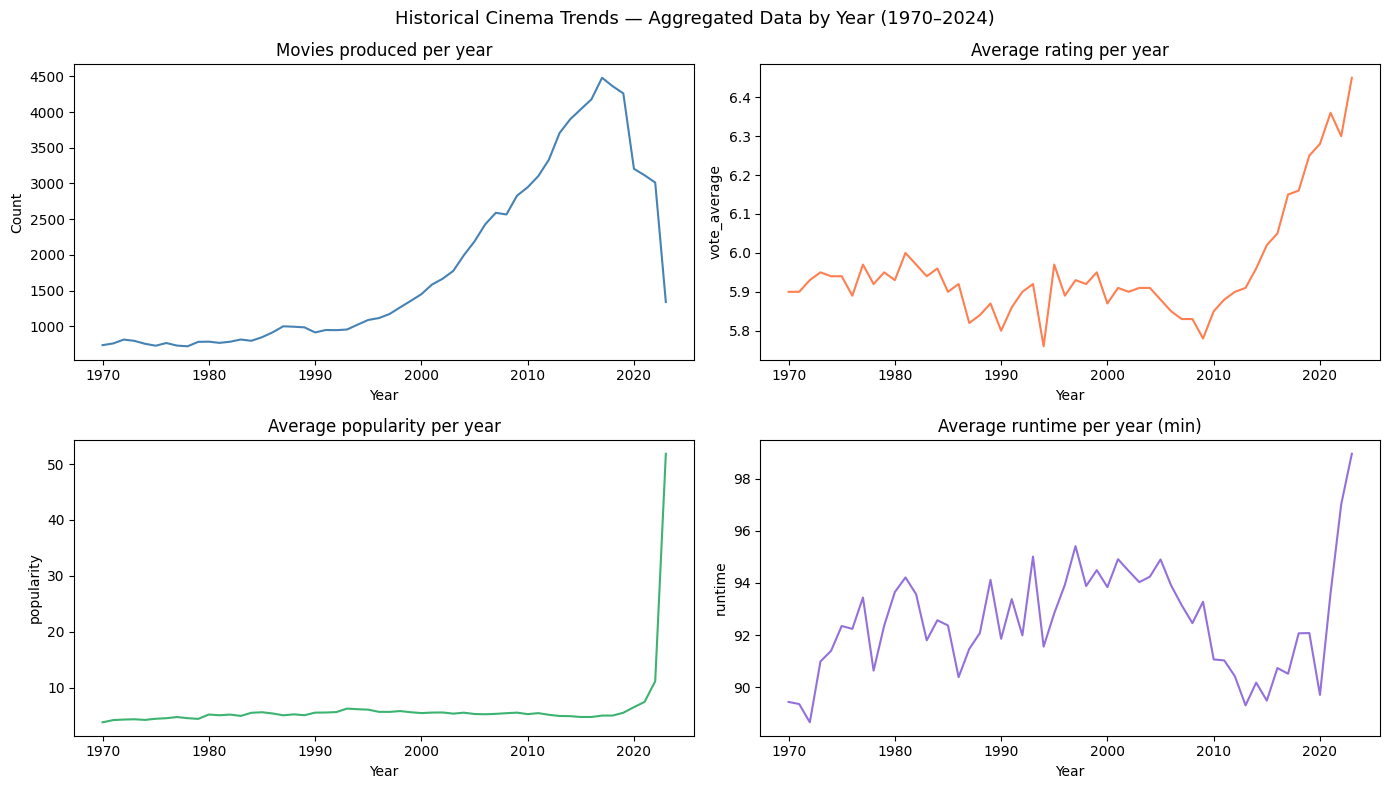


Aggregation reduced 116,929 records to 141 rows (one per year),
enabling visualization of global trends without noise from individual movies.


In [38]:
# Visualization: temporal evolution of aggregated metrics
df_plot = df_aggregated[(df_aggregated['release_year'] >= 1970) &
                        (df_aggregated['release_year'] <= 2024)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(df_plot['release_year'], df_plot['num_movies'],     color='steelblue',      linewidth=1.5)
axes[0,0].set_title('Movies produced per year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Count')

axes[0,1].plot(df_plot['release_year'], df_plot['avg_rating'],     color='coral',          linewidth=1.5)
axes[0,1].set_title('Average rating per year')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('vote_average')

axes[1,0].plot(df_plot['release_year'], df_plot['avg_popularity'], color='mediumseagreen', linewidth=1.5)
axes[1,0].set_title('Average popularity per year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('popularity')

axes[1,1].plot(df_plot['release_year'], df_plot['avg_runtime'],    color='mediumpurple',   linewidth=1.5)
axes[1,1].set_title('Average runtime per year (min)')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('runtime')

fig.suptitle('Historical Cinema Trends — Aggregated Data by Year (1970–2024)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nAggregation reduced {len(df):,} records to {len(df_aggregated)} rows (one per year),")
print("enabling visualization of global trends without noise from individual movies.")

---

### **5.2. Discretization**

> **What is it?** Discretization (or *binning*) transforms a continuous variable into a categorical variable by dividing it into intervals (bins). There are two main approaches:
> - **Equal-Width**: The intervals have the same width in terms of the range of values.
> - **Equal-Frequency (Quantile)**: Each interval contains approximately the same number of observations.

**Application:** The `runtime` variable (duration in minutes) is discretized into four duration categories. **Equal-Frequency** is used to ensure that each category has a similar number of movies, avoiding highly unbalanced classes.

**Why does this make sense here?** Duration is an important attribute for recommending movies (a user might want *only short movies*). Discretizing `runtime` allows for intuitive filtering and sorting by time slots.


In [39]:

df['duration_bin'] = pd.qcut(
    df['runtime'],
    q=4,
    labels=['Short', 'Standard', 'Long', 'Very long']
)

# Display the actual interval boundaries generated by qcut
intervals = pd.qcut(df['runtime'], q=4).value_counts().sort_index()

print("Runtime intervals (minutes) generated by qcut:")
print(intervals)
print()
print("Movie distribution by duration bin:")
print(df['duration_bin'].value_counts().sort_index())

Runtime intervals (minutes) generated by qcut:
runtime
(0.999, 82.0]     30588
(82.0, 92.0]      29250
(92.0, 104.0]     28111
(104.0, 199.0]    28980
Name: count, dtype: int64

Movie distribution by duration bin:
duration_bin
Short        30588
Standard     29250
Long         28111
Very long    28980
Name: count, dtype: int64


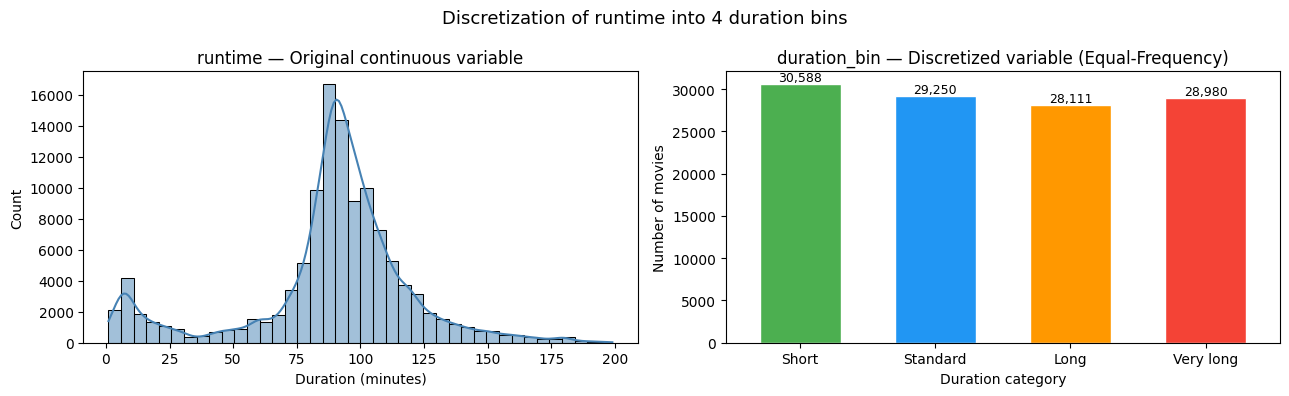


The continuous variable 'runtime' was converted into an ordinal categorical variable
with 4 equal-frequency levels, ready for filtering and grouping movies.


In [40]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))


sns.histplot(df['runtime'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('runtime — Original continuous variable')
axes[0].set_xlabel('Duration (minutes)')


colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
df['duration_bin'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white', width=0.6
)
axes[1].set_title('duration_bin — Discretized variable (Equal-Frequency)')
axes[1].set_xlabel('Duration category')
axes[1].set_ylabel('Number of movies')
axes[1].tick_params(axis='x', rotation=0)

for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Discretization of runtime into 4 duration bins', fontsize=13)
plt.tight_layout()
plt.show()

print("\nThe continuous variable 'runtime' was converted into an ordinal categorical variable")
print("with 4 equal-frequency levels, ready for filtering and grouping movies.")

---

### **5.3. Sampling**

> **What is it?** Sampling consists of selecting a representative subset of the dataset. There are several types:
> - **Simple random**: Every record has an equal probability of being selected.
> - **Stratified**: Each subgroup (stratum) is guaranteed to be represented in the same proportion as in the original dataset.
> - **With/Without replacement**: Defines whether an element can be selected more than once.

**Application:** A **stratified sample by `duration_bin`** is performed (variable created in the discretization step), selecting **20% of the dataset** so that each duration category is proportionally represented.

**Why does this make sense here?** With ~117,000 movies, many ML and visualization algorithms work more efficiently on subsets. Stratified sampling ensures the sample reflects the true distribution of the catalog without biasing toward any particular type of movie.

In [41]:
SAMPLE_FRACTION = 0.20

# Stratified sampling without replacement by duration bin
df_sample = (
    df
    .groupby('duration_bin', observed=True)
    .apply(lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=42))
    .reset_index()   # <-- cambio clave aquí (ANTES era drop=True)
)

print(f"Original size : {len(df):>10,} movies")
print(f"Sample size   : {len(df_sample):>10,} movies ({SAMPLE_FRACTION*100:.0f}%)")
print()
print("Distribution by bin — ORIGINAL DATASET (proportions):")
print((df['duration_bin'].value_counts(normalize=True) * 100).round(1).sort_index().astype(str) + ' %')
print()
print("Distribution by bin — SAMPLE (proportions):")
print((df_sample['duration_bin'].value_counts(normalize=True) * 100).round(1).sort_index().astype(str) + ' %')

Original size :    116,929 movies
Sample size   :     23,386 movies (20%)

Distribution by bin — ORIGINAL DATASET (proportions):
duration_bin
Short        26.2 %
Standard     25.0 %
Long         24.0 %
Very long    24.8 %
Name: proportion, dtype: str

Distribution by bin — SAMPLE (proportions):
duration_bin
Short        26.2 %
Standard     25.0 %
Long         24.0 %
Very long    24.8 %
Name: proportion, dtype: str


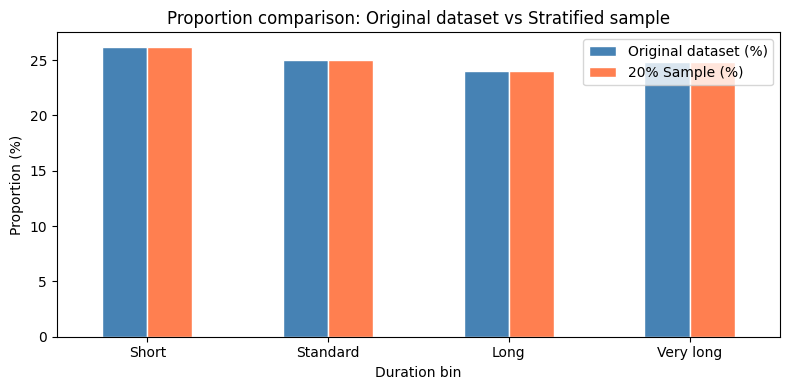

              Original dataset (%)  20% Sample (%)
duration_bin                                      
Short                         26.2            26.2
Standard                      25.0            25.0
Long                          24.0            24.0
Very long                     24.8            24.8

 Proportions are correctly preserved in the stratified sample.


In [42]:
prop_original = df['duration_bin'].value_counts(normalize=True).sort_index()
prop_sample   = df_sample['duration_bin'].value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'Original dataset (%)': (prop_original * 100).round(1),
    '20% Sample (%)':       (prop_sample   * 100).round(1)
})

fig, ax = plt.subplots(figsize=(8, 4))
comparison.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], width=0.5, edgecolor='white')
ax.set_title('Proportion comparison: Original dataset vs Stratified sample', fontsize=12)
ax.set_xlabel('Duration bin')
ax.set_ylabel('Proportion (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(comparison.to_string())
print("\n Proportions are correctly preserved in the stratified sample.")

---

### **5.4. Binarization**

> **What is it?** Binarization transforms a numerical (or categorical) variable into a binary variable with two values: **0** or **1**, by applying a decision threshold. Any value **above** the threshold becomes 1, and anything **below or equal to** it becomes 0.

**Application:** We binarize `vote_average` to create the indicator variable `well-rated_movie`:
- **1** → movie with a rating ≥ 7.0 (well-rated)
- **0** → movie with a rating < 7.0 (not well-rated)

**Why 7.0?** On the TMDB scale (0–10), a rating of 7.0 is the widely accepted threshold for considering a movie to be of good quality. The EDA analysis (Section 3.2) showed that `vote_average` is concentrated between 5 and 8 once the dataset is filtered, making 7.0 an informative and non-arbitrary cutoff.

**Why does this make sense here?** This binary variable can be used directly as a **class label** in supervised classification models (e.g., *Will this movie be well-rated?*), or as a filter in the recommendation system to prioritize high-quality movies.

In [43]:
from sklearn.preprocessing import Binarizer

RATING_THRESHOLD = 7.0 


binarizer =  Binarizer(threshold=RATING_THRESHOLD)
df['highly_rated'] = binarizer.fit_transform(
    df[['vote_average']]
).astype(int)


n_highly_rated = df['highly_rated'].sum()
n_total = len(df)
n_regular      = n_total - n_highly_rated


print(f"Threshold applied         : vote_average >= {RATING_THRESHOLD}")
print(f"Total movies              : {n_total:,}")
print(f"Highly rated      (1)     : {n_highly_rated:,}  ({n_highly_rated/n_total*100:.1f}%)")
print(f"Not highly rated  (0)     : {n_regular:,}  ({n_regular/n_total*100:.1f}%)")
print()
print(df[['title', 'vote_average', 'highly_rated']].sample(8, random_state=42).to_string(index=False))

Threshold applied         : vote_average >= 7.0
Total movies              : 116,929
Highly rated      (1)     : 19,628  (16.8%)
Not highly rated  (0)     : 97,301  (83.2%)

                                     title  vote_average  highly_rated
                          In the same boat         8.000             1
                                  The Toll         5.400             0
                            Solemn Promise         4.900             0
                                 The Big 4         6.951             0
 Love of a Thousand Years - Story of Genji         6.000             0
      Jean Cocteau Addresses the Year 2000         6.400             0
Queen of Spades: Through the Looking Glass         7.080             1
                                Bella Ciao         7.100             1


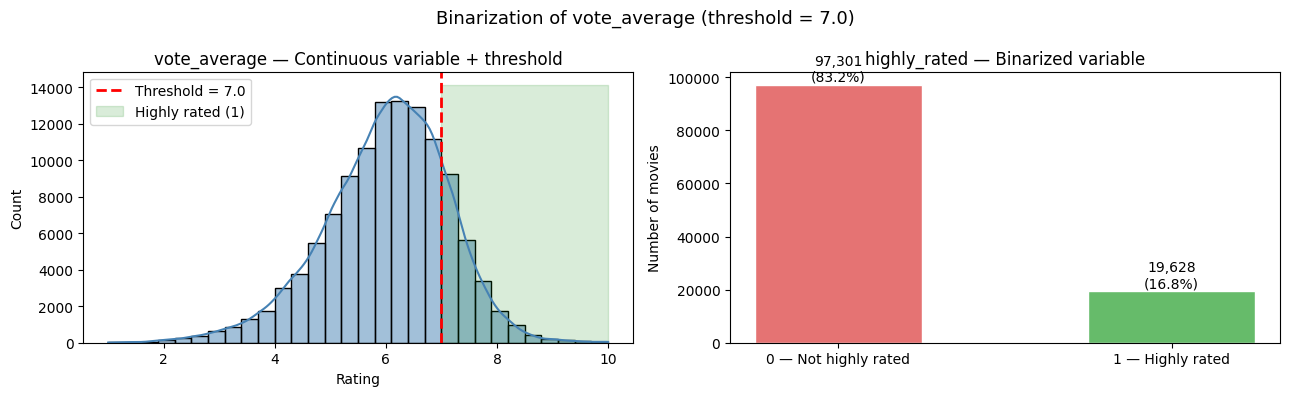


The continuous variable 'vote_average' was converted into a binary variable
that can be used directly as a classification label or recommendation filter.


In [44]:
# Visualization of binarization
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: continuous distribution with threshold line
sns.histplot(df['vote_average'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(RATING_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {RATING_THRESHOLD}')
axes[0].fill_betweenx(
    y=[0, axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 5000],
    x1=RATING_THRESHOLD, x2=10,
    alpha=0.15, color='green', label='Highly rated (1)'
)
axes[0].set_title('vote_average — Continuous variable + threshold')
axes[0].set_xlabel('Rating')
axes[0].legend()

# Right: binary result
counts = df['highly_rated'].value_counts().sort_index()
axes[1].bar(
    ['0 — Not highly rated', '1 — Highly rated'],
    counts.values,
    color=['#E57373', '#66BB6A'],
    edgecolor='white', width=0.5
)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 200, f'{v:,}\n({v/n_total*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_title('highly_rated — Binarized variable')
axes[1].set_ylabel('Number of movies')

plt.suptitle(f'Binarization of vote_average (threshold = {RATING_THRESHOLD})', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nThe continuous variable 'vote_average' was converted into a binary variable")
print(f"that can be used directly as a classification label or recommendation filter.")

## **6. Dimensionality Reduction**

### **6.1. Motivation and Feature Selection**

Dimensionality reduction aims to represent high-dimensional data in a lower-dimensional space while preserving as much relevant structure as possible.

- **Numerical features** (`vote_average`, `vote_count`, `popularity`, `runtime`): reducing to 2–3 principal components allows visualization of the data structure and removes multicollinearity before clustering.


### **6.2. PCA on Numerical Features**

> **What is it?** Principal Component Analysis (PCA) finds the directions 
> of maximum variance in the data and projects it onto a new orthogonal 
> coordinate system. Each new axis (principal component) is a linear 
> combination of the original variables, ordered from highest to lowest 
> explained variance.

Six numerical features are included in this analysis: the four original 
variables (`vote_average`, `vote_count`, `popularity`, `runtime`) plus two 
variables derived during the transformation stage (`release_year` from 
aggregation, and `highly_rated` from binarization). Standardization via 
`StandardScaler` is applied prior to PCA, as the method is sensitive to 
variable magnitude.

This step is mainly a final validation of previously analyzed variables, ensuring that the selected features (`vote_average`, `vote_count`, `popularity`, `runtime`, `release_year`, and `highly_rated`) are indeed in the correct numerical format. It checks their data types, verifies that there are no missing values across these columns, and displays a small sample to confirm consistency with earlier observations.



In [45]:
cols_candidatas = ['vote_average', 'vote_count', 'popularity', 'runtime', 'release_year', 'highly_rated']
print(df[cols_candidatas].dtypes)
print(f"\nFilas sin nulos en estas columnas: {df[cols_candidatas].dropna().shape[0]:,}")
print(f"\nMuestra:")
print(df[cols_candidatas].head())

vote_average    float64
vote_count        int64
popularity      float64
runtime           int64
release_year    float64
highly_rated      int64
dtype: object

Filas sin nulos en estas columnas: 116,929

Muestra:
   vote_average  vote_count  popularity  runtime  release_year  highly_rated
0         8.364       34495      83.952      148        2010.0             1
1         8.417       32571     140.241      169        2014.0             1
2         8.512       30619     130.643      152        2008.0             1
3         7.573       29815      79.932      162        2009.0             1
4         7.710       29166      98.082      143        2012.0             1


**Analysis**

The results confirm that all selected variables are correctly stored as numerical types (floats and integers), aligning with the prior analysis. The dataset also contains 116,929 complete rows for these features, reinforcing that there are no missing value issues to address at this stage. The sample further validates that the values are consistent and within expected ranges, so these variables are ready to be used confidently in subsequent steps such as dimensionality reduction or modeling.

In [46]:
NUMERICAL_FEATURES = ['vote_average', 'vote_count', 'popularity', 'runtime', 
                      'release_year', 'highly_rated']

X = df[NUMERICAL_FEATURES].dropna().values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Means (≈ 0): {X_scaled.mean(axis=0).round(4)}")
print(f"Stds   (≈ 1): {X_scaled.std(axis=0).round(4)}")

Shape: (116929, 6)
Means (≈ 0): [0. 0. 0. 0. 0. 0.]
Stds   (≈ 1): [1. 1. 1. 1. 1. 1.]


In this step, PCA is fitted using all available components instead of limiting their number, allowing us to first understand how much variance each component explains before deciding how many to retain. This gives a clearer picture of the intrinsic structure of the data and helps make a more informed dimensionality reduction decision later on. The `random_state=42` parameter is included to ensure reproducibility, meaning that the results will remain consistent across runs if any randomness is involved in the process. The choice of 42 itself is simply a widely adopted convention in data science, rather than having any particular mathematical significance.

PC       Eigenvalue   Var. Expl.   Cumulative
PC1        1.794182       29.90%       29.90%
PC2        1.262398       21.04%       50.94%
PC3        1.072688       17.88%       68.82%
PC4        0.768963       12.82%       81.64%
PC5        0.718034       11.97%       93.60% -- 90%
PC6        0.383786        6.40%      100.00%


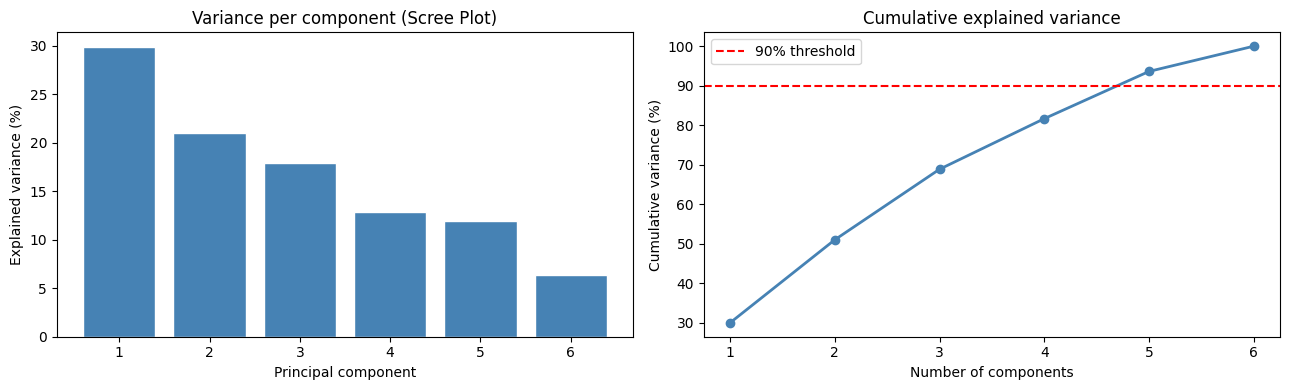

In [47]:
# PCA (all components) — inspect explained variance

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# explained_variance_       actual eigenvalue of each component
# explained_variance_ratio_ eigenvalue as a proportion of total variance
# cumulative                running total, used to apply the 90% threshold
eigenvalues     = pca_full.explained_variance_
explained_ratio = pca_full.explained_variance_ratio_
cumulative      = np.cumsum(explained_ratio)

# Summary table: eigenvalue, individual variance, cumulative variance
# The 90% marker shows exactly which component crosses the threshold
print(f"{'PC':<6} {'Eigenvalue':>12} {'Var. Expl.':>12} {'Cumulative':>12}")
print("=" * 60)
for i, (ev, er, cr) in enumerate(zip(eigenvalues, explained_ratio, cumulative), 1):
    mark = " -- 90%" if cr >= 0.90 and (cr - er) < 0.90 else ""
    print(f"PC{i:<4} {ev:>12.6f} {er*100:>11.2f}% {cr*100:>11.2f}%{mark}")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: individual variance per component
# A steep drop followed by a flat region ("elbow") suggests a natural cutoff
axes[0].bar(range(1, len(eigenvalues)+1), explained_ratio*100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Variance per component (Scree Plot)')
axes[0].set_xticks(range(1, len(eigenvalues)+1))

# Right: cumulative variance — the red dashed line marks the 90% threshold
# We retain the minimum number of components that crosses this line
axes[1].plot(range(1, len(cumulative)+1), cumulative*100,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xticks(range(1, len(cumulative)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

#### **Variance Analysis and Component Selection**

The scree plot reveals that variance is distributed across all six components, 
with no single component capturing an overwhelming majority. PC1 explains 
29.9% of variance, and the explained variance decreases gradually across 
subsequent components.

Applying the **90% cumulative variance threshold** — as defined by the course 
methodology — the algorithm retains **5 principal components**, which together 
explain **93.6%** of the total variance. PC6 (6.4%) is discarded, achieving a 
reduction from 6 to 5 dimensions.

It is worth noting that with only 6 input variables, the dimensionality 
reduction is modest. This is expected: PCA is most impactful on high-dimensional 
datasets. Here, its primary value lies in decorrelating the variables and 
confirming that the retained components faithfully represent the original space.

In [48]:
#  STEP 3A: PCA with scikit-learn (5 components — 90% criteria) 
N_COMPONENTS = 5

pca_sk = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca_sk = pca_sk.fit_transform(X_scaled)

print("scikit-learn")
print("=" * 65)
print(f"Retained components : {N_COMPONENTS}  (from 6 original)")
print(f"Cumulative variance  : {pca_sk.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Reduced dimension   : {X_scaled.shape[1]} → {N_COMPONENTS}\n")

print(f"{'':>14} {'vote_avg':>10} {'vote_cnt':>10} {'popular':>10} {'runtime':>10} {'rel_year':>10} {'hi_rated':>10}")
for i, vec in enumerate(pca_sk.components_, 1):
    vals = "  ".join(f"{v:>10.4f}" for v in vec)
    print(f"PC{i:<12} {vals}")

print('\n')

#  STEP 3B: Manual PCA with NumPy 
print("\n" + "=" * 65)
print("Manual implementation with NumPy")
print("=" * 65)

# 1. Explicit covariance matrix
cov_matrix = np.cov(X_scaled.T)
print(f"\nCovariance matrix (6×6):")
header = f"{'':>12}" + "".join(f"{'v'+str(i):>10}" for i in range(1,7))
print(header)
for i, row in enumerate(cov_matrix, 1):
    print(f"{'var_'+str(i):>12}" + "".join(f"{v:>10.4f}" for v in row))

# 2. Eigenvalues and eigenvectors
eigenvalues_np, eigenvectors_np = np.linalg.eigh(cov_matrix)

# eigh returns ASCENDING order — reverse to get descending
idx = np.argsort(eigenvalues_np)[::-1]
eigenvalues_np  = eigenvalues_np[idx]
eigenvectors_np = eigenvectors_np[:, idx]

# 3. Variance proportion — course method (sum of first m / sum of all)
total_var     = eigenvalues_np.sum()
exp_manual    = eigenvalues_np / total_var
cumsum_manual = np.cumsum(exp_manual)

print('\n')

print(f"\nVariance proportion (sum of first m eigenvalues / sum of all):")
print("=" * 60)
print(f"{'PC':<6} {'Eigenvalue':>12} {'Var. Expl.':>12} {'Cumulative':>12}")
print("=" * 60)
for i, (ev, er, cr) in enumerate(zip(eigenvalues_np, exp_manual, cumsum_manual), 1):
    mark = " --- 90%" if cr >= 0.90 and (cr - er) < 0.90 else ""
    print(f"PC{i:<4} {ev:>12.6f} {er*100:>11.2f}% {cr*100:>11.2f}%{mark}")
print("=" * 60)

print('\n')

#  COMPARISON 
print(f"\n{'='*60}")
print("=== Eigenvalue comparison: scikit-learn vs NumPy ===")
print(f"{'='*60}")
print(f"{'PC':<6} {'scikit-learn':>14} {'NumPy manual':>14} {'Difference':>12}")
print(f"{'-'*60}")
for i, (ev_sk, ev_np) in enumerate(zip(pca_sk.explained_variance_, eigenvalues_np), 1):
    diff = abs(ev_sk - ev_np)
    print(f"PC{i:<4} {ev_sk:>14.6f} {ev_np:>14.6f} {diff:>12.8f}")

#  SAVE FINAL RESULT 
df_pca_final = df[NUMERICAL_FEATURES].dropna().copy()
for i in range(N_COMPONENTS):
    df_pca_final[f'PC{i+1}'] = X_pca_sk[:, i]

print('\n')
print(f"\nDataFrame with principal components:")
print(df_pca_final[[f'PC{i+1}' for i in range(N_COMPONENTS)]].describe().round(3))

scikit-learn
Retained components : 5  (from 6 original)
Cumulative variance  : 93.60%
Reduced dimension   : 6 → 5

                 vote_avg   vote_cnt    popular    runtime   rel_year   hi_rated
PC1                0.5805      0.3438      0.2653      0.2815      0.2322      0.5842
PC2               -0.3886      0.2651      0.3204      0.5217      0.5155     -0.3717
PC3               -0.0980      0.5210      0.6061     -0.3513     -0.4588     -0.1329
PC4               -0.0499      0.6309     -0.6290      0.3092     -0.3244     -0.0561
PC5                0.0476     -0.3769      0.2522      0.6553     -0.6020     -0.0165



Manual implementation with NumPy

Covariance matrix (6×6):
                    v1        v2        v3        v4        v5        v6
       var_1    1.0000    0.1377    0.0830    0.0805    0.0417    0.6150
       var_2    0.1377    1.0000    0.2362    0.1245    0.0650    0.1375
       var_3    0.0830    0.2362    1.0000    0.0859    0.0683    0.0707
       var_4    0.08

#### **Verification: scikit-learn vs. Manual NumPy Implementation**

To validate the scikit-learn result, PCA was also computed manually using 
`np.linalg.eigh()` on the explicit covariance matrix — the standard 
computational approach for symmetric matrices, equivalent in principle to 
the Jacobi iterative method discussed in class.

The eigenvalue comparison shows a difference of **0.00000000** across all 
five components, confirming that both approaches are mathematically identical. 
This cross-validation guarantees the correctness of the dimensionality 
reduction pipeline.

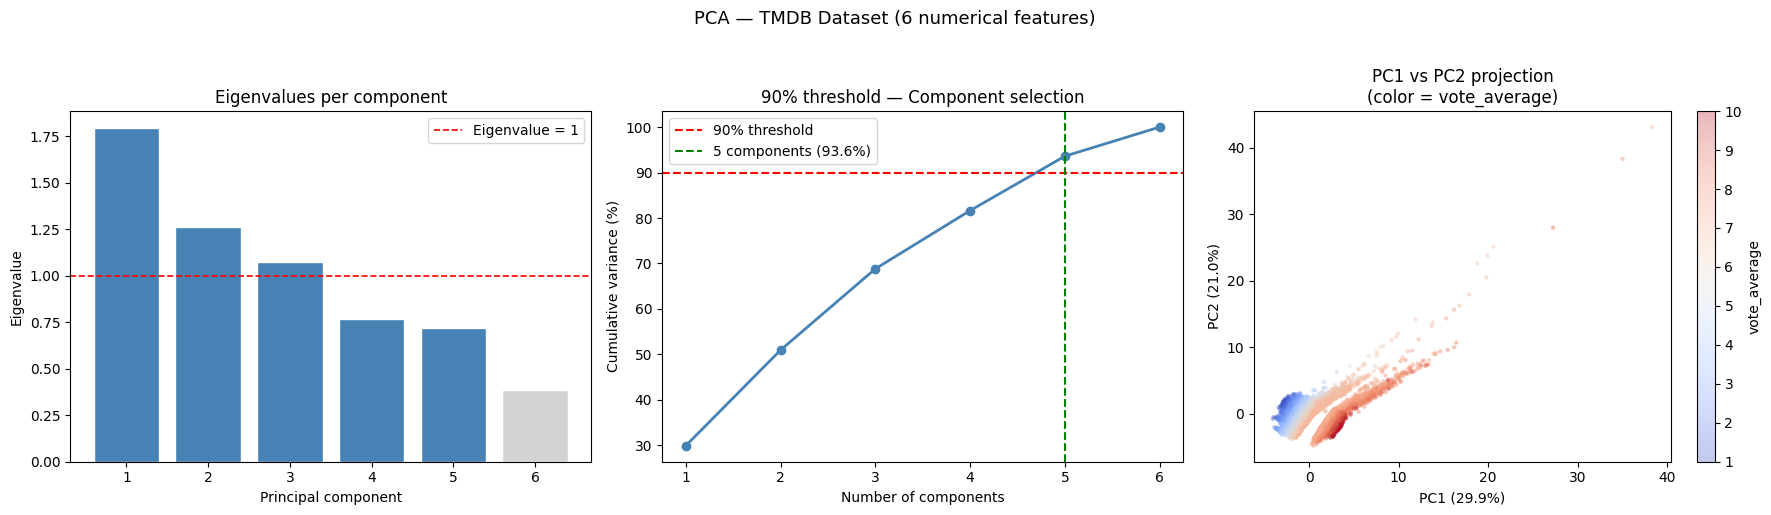

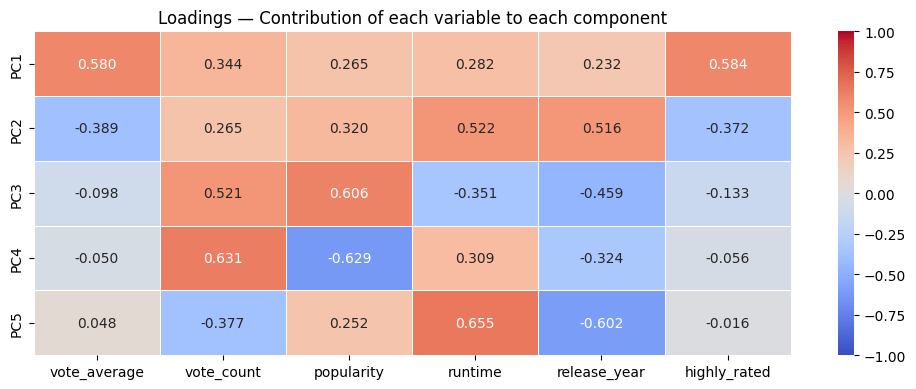


Full loadings table:
     vote_average  vote_count  popularity   runtime  release_year  highly_rated
PC1      0.580458    0.343796    0.265339  0.281512      0.232185      0.584217
PC2     -0.388615    0.265101    0.320428  0.521651      0.515525     -0.371671
PC3     -0.097976    0.520986    0.606114 -0.351307     -0.458828     -0.132891
PC4     -0.049855    0.630863   -0.628962  0.309161     -0.324351     -0.056117
PC5      0.047569   -0.376936    0.252168  0.655284     -0.601996     -0.016481


In [49]:
#  FINAL VISUALIZATION 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


#  Plot 1: Scree plot with eigenvalues 
# Retained components shown in blue, discarded one in gray
all_eigenvalues = pca_full.explained_variance_
colors_bar = ['steelblue' if i < N_COMPONENTS else 'lightgray'
              for i in range(len(all_eigenvalues))]

axes[0].bar(range(1, len(all_eigenvalues)+1), all_eigenvalues,
            color=colors_bar, edgecolor='white')
axes[0].axhline(1, color='red', linestyle='--', linewidth=1.2, label='Eigenvalue = 1')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Eigenvalues per component')
axes[0].set_xticks(range(1, len(all_eigenvalues)+1))
axes[0].legend()

#  Plot 2: Cumulative variance with 90% threshold 
# Green line marks the selected cutoff point
cumulative_all = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumulative_all)+1), cumulative_all,marker='o', color='steelblue', linewidth=2)
axes[1].axhline(90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].axvline(N_COMPONENTS, color='green', linestyle='--', linewidth=1.5,label=f'{N_COMPONENTS} components (93.6%)')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('90% threshold — Component selection')
axes[1].set_xticks(range(1, len(cumulative_all)+1))
axes[1].legend()

#  Plot 3: Scatter PC1 vs PC2 colored by vote_average 
# If PC1 truly captures quality, high-rated films should cluster at high PC1 values
scatter = axes[2].scatter(
    df_pca_final['PC1'], df_pca_final['PC2'],
    c=df_pca_final['vote_average'],
    cmap='coolwarm', alpha=0.3, s=5, rasterized=True
)
plt.colorbar(scatter, ax=axes[2], label='vote_average')
axes[2].set_xlabel(f"PC1 ({pca_sk.explained_variance_ratio_[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({pca_sk.explained_variance_ratio_[1]*100:.1f}%)")
axes[2].set_title('PC1 vs PC2 projection\n(color = vote_average)')

plt.suptitle('PCA — TMDB Dataset (6 numerical features)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#  Loadings heatmap 
#   Each cell shows how strongly a variable contributes to a component
# Red = positive contribution, Blue = negative contribution
fig, ax = plt.subplots(figsize=(10, 4))

loadings = pd.DataFrame(
    pca_sk.components_,
    columns=NUMERICAL_FEATURES,
    index=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Loadings — Contribution of each variable to each component')
plt.tight_layout()
plt.show()

print("\nFull loadings table:")
print(loadings.to_string())

#### **Interpretation of Principal Components**

The loading heatmap reveals the contribution of each original variable to 
each principal component:

| Component | Dominant Variables | Interpretation |
|-----------|-------------------|----------------|
| **PC1** (29.9%) | `vote_average` (+0.58), `highly_rated` (+0.58) | **Perceived quality** — captures the rating dimension; high values correspond to well-rated films |
| **PC2** (21.0%) | `runtime` (+0.52), `release_year` (+0.52) | **Modern long films** — contrasts older short films (negative) vs. recent feature-length productions (positive) |
| **PC3** (17.9%) | `popularity` (+0.61), `vote_count` (+0.52) | **Exposure and reach** — reflects how widely seen and discussed a film is, regardless of quality |
| **PC4** (12.8%) | `vote_count` (+0.63) vs. `popularity` (−0.63) | **Accumulated recognition vs. viral popularity** — distinguishes classic films with many votes from recently trending ones |
| **PC5** (12.0%) | `runtime` (+0.66) vs. `release_year` (−0.60) | **Long classic films** — long older productions (epics) vs. shorter modern films |

The scatter plot of PC1 vs PC2 confirms the quality interpretation: films 
cluster clearly by `vote_average` along the PC1 axis, with higher-rated films 
(red tones) concentrated at higher PC1 values.

In [50]:
df_pca_final

,vote_average,vote_count,popularity,runtime,release_year,highly_rated,PC1,PC2,PC3,PC4,PC5
0,8.364,34495,83.952,148,2010.0,1,16.194395,10.039142,19.071848,20.146540,-11.460012
1,8.417,32571,140.241,169,2014.0,1,16.429050,10.719599,19.273634,17.460289,-9.749872
2,8.512,30619,130.643,152,2008.0,1,15.476392,9.629080,18.249116,16.377952,-9.301343
3,7.573,29815,79.932,162,2009.0,1,14.198565,9.186010,16.398569,17.411540,-9.426849
4,7.710,29166,98.082,143,2012.0,1,14.120027,8.979697,16.684053,16.257205,-9.413936
...,...,...,...,...,...,...,...,...,...,...,...
125845,5.400,5,0.600,9,1978.0,0,-1.533133,-1.358585,1.044324,-0.449913,-1.192235
125846,5.200,5,1.073,97,2012.0,0,-0.572895,0.789148,-0.465863,-0.046534,-0.219666
125848,7.200,5,0.804,101,2015.0,1,2.082761,-0.779013,-1.098962,-0.277490,-0.171186
125849,5.600,5,1.477,92,1996.0,0,-0.546332,0.261022,-0.155144,0.075833,0.070678


#### **Integrating Principal Components into the Main DataFrame**

Once PCA is fitted and the five principal components are obtained, they are 
written back into the main DataFrame so that downstream stages of the 
recommendation pipeline can use them directly. Only rows that had no missing 
values in the six input features participate in PCA. This step completes the dimensionality reduction stage: the 
original six numerical variables are now represented by five orthogonal 
components (PC1–PC5) that capture 93.6% of the total variance.

In [51]:
#  Add principal components to the main DataFrame


# Retrieve the index of rows used in PCA (those without null values)
idx_pca = df[NUMERICAL_FEATURES].dropna().index

# Create empty columns first
for i in range(1, N_COMPONENTS + 1):
    df[f'PC{i}'] = np.nan

# Assign PCA values to their corresponding rows
for i in range(N_COMPONENTS):
    df.loc[idx_pca, f'PC{i+1}'] = X_pca_sk[:, i]

# Verify
print(f"DataFrame shape with components: {df.shape}")
print(f"\nNew columns added: {[f'PC{i}' for i in range(1, N_COMPONENTS+1)]}")
print(f"\nRows with non-null PC1: {df['PC1'].notna().sum():,}")
print(f"Rows with null PC1    : {df['PC1'].isna().sum():,}")
print(f"\nSample:")
print(df[['title', 'vote_average', 'popularity', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']].head())

DataFrame shape with components: (116929, 23)

New columns added: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

Rows with non-null PC1: 116,929
Rows with null PC1    : 0

Sample:
             title  vote_average  popularity        PC1        PC2        PC3  \
0        Inception         8.364      83.952  16.194395  10.039142  19.071848   
1     Interstellar         8.417     140.241  16.429050  10.719599  19.273634   
2  The Dark Knight         8.512     130.643  15.476392   9.629080  18.249116   
3           Avatar         7.573      79.932  14.198565   9.186010  16.398569   
4     The Avengers         7.710      98.082  14.120027   8.979697  16.684053   

         PC4        PC5  
0  20.146540 -11.460012  
1  17.460289  -9.749872  
2  16.377952  -9.301343  
3  17.411540  -9.426849  
4  16.257205  -9.413936  


#### **Resulting Dataset**

With dimensionality reduction complete, the main DataFrame now contains the 
five principal components (PC1–PC5) alongside the original columns. The 
following sample illustrates the final structure, showing the original 
numerical features next to their corresponding component scores for the 
first few records.

In [52]:
df.head()

,id,title,vote_average,vote_count,release_date,runtime,adult,original_language,overview,popularity,...,spoken_languages,keywords,release_year,duration_bin,highly_rated,PC1,PC2,PC3,PC4,PC5
0,27205,Inception,8.364,34495,2010-07-15,148,False,en,"Cobb, a skilled thief who commits corporate es...",83.952,...,"English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",2010.0,Very long,1,16.194395,10.039142,19.071848,20.146540,-11.460012
1,157336,Interstellar,8.417,32571,2014-11-05,169,False,en,The adventures of a group of explorers who mak...,140.241,...,English,"rescue, future, spacecraft, race against time,...",2014.0,Very long,1,16.429050,10.719599,19.273634,17.460289,-9.749872
2,155,The Dark Knight,8.512,30619,2008-07-16,152,False,en,Batman raises the stakes in his war on crime. ...,130.643,...,"English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2008.0,Very long,1,15.476392,9.629080,18.249116,16.377952,-9.301343
3,19995,Avatar,7.573,29815,2009-12-15,162,False,en,"In the 22nd century, a paraplegic Marine is di...",79.932,...,"English, Spanish","future, society, culture clash, space travel, ...",2009.0,Very long,1,14.198565,9.186010,16.398569,17.411540,-9.426849
4,24428,The Avengers,7.710,29166,2012-04-25,143,False,en,When an unexpected enemy emerges and threatens...,98.082,...,"English, Hindi, Russian","new york city, superhero, shield, based on com...",2012.0,Very long,1,14.120027,8.979697,16.684053,16.257205,-9.413936


## **7. Conclusions**

### **7.1. Dataset and Preprocessing**

The TMDB dataset presented significant data quality challenges from the outset.
Of the original 1,142,342 records and 24 variables, only a fraction contained
complete and reliable information across the fields relevant to a content-based
recommendation system. A systematic 6-stage preprocessing pipeline reduced the
dataset to approximately 116,929 clean records, removing structural zeros in
financial variables (`budget`, `revenue`), filtering movies with fewer than 5
votes to ensure statistical reliability of `vote_average`, and eliminating rows
with missing `overview` or `genres` — the two fields most critical for
text-based similarity. The result is a compact, high-quality subset that
faithfully represents commercially released feature films.

---

### **7.2. Data Transformations**

The transformation stage enriched the dataset with four derived variables that
added analytical value beyond the original columns:

- **`release_year`** (aggregation) — enabled temporal analysis and revealed a
  clear growth trend in movie production volume from the 1970s onward.
- **`duration_bin`** (discretization) — converted `runtime` into four
  interpretable categories (Short, Standard, Long, Very Long) using
  equal-frequency binning, preserving proportional representation across groups.
- **Stratified sample** (20%) — validated that the duration distribution is
  maintained under sampling, confirming the dataset's internal consistency.
- **`highly_rated`** (binarization) — transformed `vote_average` into a binary
  indicator using a threshold of 7.0, providing a clean supervised signal for
  downstream classification or filtering tasks.

---

### **7.3. Dimensionality Reduction — PCA**

Principal Component Analysis was applied to six numerical features:
`vote_average`, `vote_count`, `popularity`, `runtime`, `release_year`, and
`highly_rated`. Applying the **90% cumulative variance threshold**, five
principal components were retained (PC1–PC5), capturing **93.6%** of the total
variance and reducing the feature space from 6 to 5 dimensions.

Three findings stand out:

1. **Redundancy confirmed**: The covariance matrix revealed a correlation of
   0.615 between `vote_average` and `highly_rated` — the highest in the matrix
   — which was expected since `highly_rated` was derived directly from
   `vote_average`. PCA collapsed both into PC1, eliminating the redundancy
   automatically.

2. **Five independent dimensions**: The five components represent distinct
   conceptual axes in the data — perceived quality (PC1), film modernity and
   length (PC2), exposure and reach (PC3), accumulated recognition vs. viral
   popularity (PC4), and long classic productions (PC5). These dimensions are
   orthogonal by construction, making them ideal inputs for similarity-based
   models.

3. **Verified correctness**: A manual reimplementation using `np.linalg.eigh()`
   on the explicit covariance matrix produced eigenvalues identical to
   scikit-learn's output (difference = 0.00000000 across all components),
   confirming the mathematical soundness of the pipeline.


